#### coauthor_extras_state_and_placebo.ipynb

**Author:** James Sayre  
**Email:** jsayre@ucdavis.edu  
**Date Modified:** 2026-05-26

**Description:** Four supplemental coauthor-extras analyses for the maize within-mun R² story.

1. State-level within-mun R² vs SD of SIAP maize yields across years (2007–2024).
2. State-level total R² + total/between/within decomposition (raw AEF Hist Ens, combined season).
3. Within-R² by exemplar muns binned by mean maize parcel size (INEGI 2022).
4. Placebo muns: contiguous random groupings of ADCs preserving the per-state mun-size distribution; histogram of placebo within-R² vs. actual.

All four use the paper's headline model: `adc_aef_hist_ens_eval.parquet` (Within-R² = 0.152, combined raw).

**Inputs:**
- `~/Dropbox/Projects/Maize_prediction/Data/predictions/adc_aef_hist_ens_eval.parquet`
- `~/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/state_accuracy.csv`
- `~/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/within_r2_mun_raw_comb.csv`
- `~/Dropbox/Projects/Maize_prediction/Data/SIAP/Cleaned/siap_ag_prod_estimation_ca2007.dta` (SIAP mun-yr maize)
- `~/Dropbox/Projects/Maize_prediction/Data/INEGI/MD_lab_outputs/LM2304-CA22-2025-09-29-superficie_ENTREGA/adc_land_use_ca22_adc07.dta` (INEGI 2022, num_up)
- `~/Dropbox/Projects/Maize_prediction/Data/Shapefiles/adc_shapefile.shp` (ADC shapefile, for placebos)
- `~/Dropbox/Projects/Avocado_Deforestation/Data/raw/spatial/Municipality_shp/STATES.shp` (state names)

**Outputs (under `~/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/`):**
- `fig_state_withinR2_vs_siapSD.png` — Task 1 scatter
- `fig_state_total_r2.png`, `fig_state_total_within_r2.png` — Task 2 bars
- `fig_parcelsize_binned_within_r2.png`, `fig_parcelsize_exemplar_muns.png` — Task 3
- `fig_placebo_within_r2_hist.png` — Task 4 histogram of placebos
- `placebo_within_r2.csv` — per-replicate placebo within-R²

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({"font.family": "serif",
                     "axes.titlesize": 12, "axes.labelsize": 11,
                     "xtick.labelsize": 9, "ytick.labelsize": 9,
                     "legend.fontsize": 9, "figure.dpi": 130})

# ── Directories ────────────────────────────────────
home_dir       =  os.path.expanduser("~")
proj_dir       =  os.path.join(home_dir, "Dropbox", "Projects", "Maize_prediction")
data_dir       =  os.path.join(proj_dir, "Data")
preds_dir      =  os.path.join(data_dir, "predictions")
out_dir        =  os.path.join(proj_dir, "plots", "coauthor_extras_paper")
inegi_dir      =  os.path.join(data_dir, "INEGI", "MD_lab_outputs",
                                "LM2304-CA22-2025-09-29-superficie_ENTREGA")
sciaga_dir     =  os.path.join(home_dir, "Dropbox", "Projects", "Crop_misallocation", "Data")
siap_pkg       =  os.path.join(home_dir, "Dropbox", "Projects",
                                "Maize_prediction", "Data", "SIAP", "Cleaned")

# ── Inputs ───────────────────────────────────────
eval_path      =  os.path.join(preds_dir,  "adc_aef_hist_ens_eval.parquet")     # paper-aligned eval (raw + corr, 95,264 rows)
state_acc_csv  =  os.path.join(out_dir,    "state_accuracy.csv")                 # 124 rows: state × season × model
mun_r2_csv     =  os.path.join(out_dir,    "within_r2_mun_raw_comb.csv")         # per-mun within-R² (raw combined)
siap_ca07_dta  =  os.path.join(siap_pkg,   "siap_ag_prod_estimation_ca2007.dta") # SIAP mun×yr×crop (1980–2024)
inegi_2022_dta =  os.path.join(inegi_dir,  "adc_land_use_ca22_adc07.dta")        # INEGI 2022 maize (land_input, num_up)
adc_shp        =  os.path.join(home_dir, "Dropbox", "Projects", "Maize_prediction", "Data", "Shapefiles", "adc_shapefile.shp")   # ADC polygons

# ── Outputs ──────────────────────────────────────
fig_t1         =  os.path.join(out_dir, "fig_state_withinR2_vs_siapSD.png")
fig_t2_total   =  os.path.join(out_dir, "fig_state_total_r2.png")
fig_t2_decomp  =  os.path.join(out_dir, "fig_state_total_within_r2.png")
fig_t3_binned  =  os.path.join(out_dir, "fig_parcelsize_binned_within_r2.png")
fig_t3_exempl  =  os.path.join(out_dir, "fig_parcelsize_exemplar_muns.png")
fig_t4_hist    =  os.path.join(out_dir, "fig_placebo_within_r2_hist.png")
placebo_csv    =  os.path.join(out_dir, "placebo_within_r2.csv")

# Constants matching coauthor_extras_paper.py
MIN_ADCS_FOR_R2 = 2
R2_CLIP_LO      = -2.0

def r2(y, yh):
    m  =  np.isfinite(y) & np.isfinite(yh)
    y, yh = np.asarray(y[m]), np.asarray(yh[m])
    if len(y) < 2: return np.nan
    st = np.sum((y - y.mean())**2)
    return 1 - np.sum((y - yh)**2) / st if st > 0 else np.nan

def within_r2(df, y, p, gc="muncode"):
    s  =  df[[y, p, gc]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    c  =  s.groupby(gc).size()
    s  =  s[s[gc].isin(c[c >= MIN_ADCS_FOR_R2].index)]
    if len(s) == 0: return np.nan
    gm = s.groupby(gc)[[y, p]].transform("mean")
    return r2(s[y] - gm[y], s[p] - gm[p])

def between_r2(df, y, p, gc="muncode"):
    s = df[[y, p, gc]].replace([np.inf, -np.inf], np.nan).dropna()
    g = s.groupby(gc)[[y, p]].mean()
    return r2(g[y], g[p])

# Load paper eval frame
df_eval = pd.read_parquet(eval_path)
df_eval["state"] = df_eval["muncode"].str[:2]
print(f"eval: {len(df_eval):,} rows, {df_eval['muncode'].nunique():,} muns, {df_eval['state'].nunique()} states")

# State names come from state_accuracy.csv (no need to read a shapefile)
state_names = (pd.read_csv(state_acc_csv, dtype={"state":str})
                 .assign(state=lambda d: d["state"].str.zfill(2))
                 [["state","state_name"]].drop_duplicates())
print(state_names.head(3))

eval: 95,264 rows, 2,071 muns, 31 states
  state           state_name
0    01       Aguascalientes
4    02      Baja California
8    03  Baja California Sur


#### Task 1 — State within-mun R² vs SIAP cross-year SD of maize yield

For each mun, SD of SIAP maize yield over 2007–2024.  
Aggregate to state by area-weighted mean (weights = mean ha_planted per mun).

SIAP maize rows 42,270, muns 2,428, yrs 2007-2024
Per-mun SD: 2,378 muns
Task 1 merged: 31 states
        state_name  state_sd_yield_wmean  state_sd_yield_med  Within_R2  n_mun
20       Queretaro              0.802944            0.497904   0.548570     18
24          Sonora              2.909787            2.077744   0.428052     23
23         Sinaloa              2.165136            2.145325   0.405266     18
10      Guanajuato              0.964598            0.996404   0.375641     46
12         Hidalgo              0.656330            0.509038   0.313313     84
9          Durango              0.830751            0.660601   0.225892     37
0   Aguascalientes              1.495560            1.652167   0.108890     11
15       Michoacan              0.844021            0.721428   0.105305    112
30       Zacatecas              1.040890            1.135619   0.103031     58
17         Nayarit              0.977812            0.925141   0.010762     20


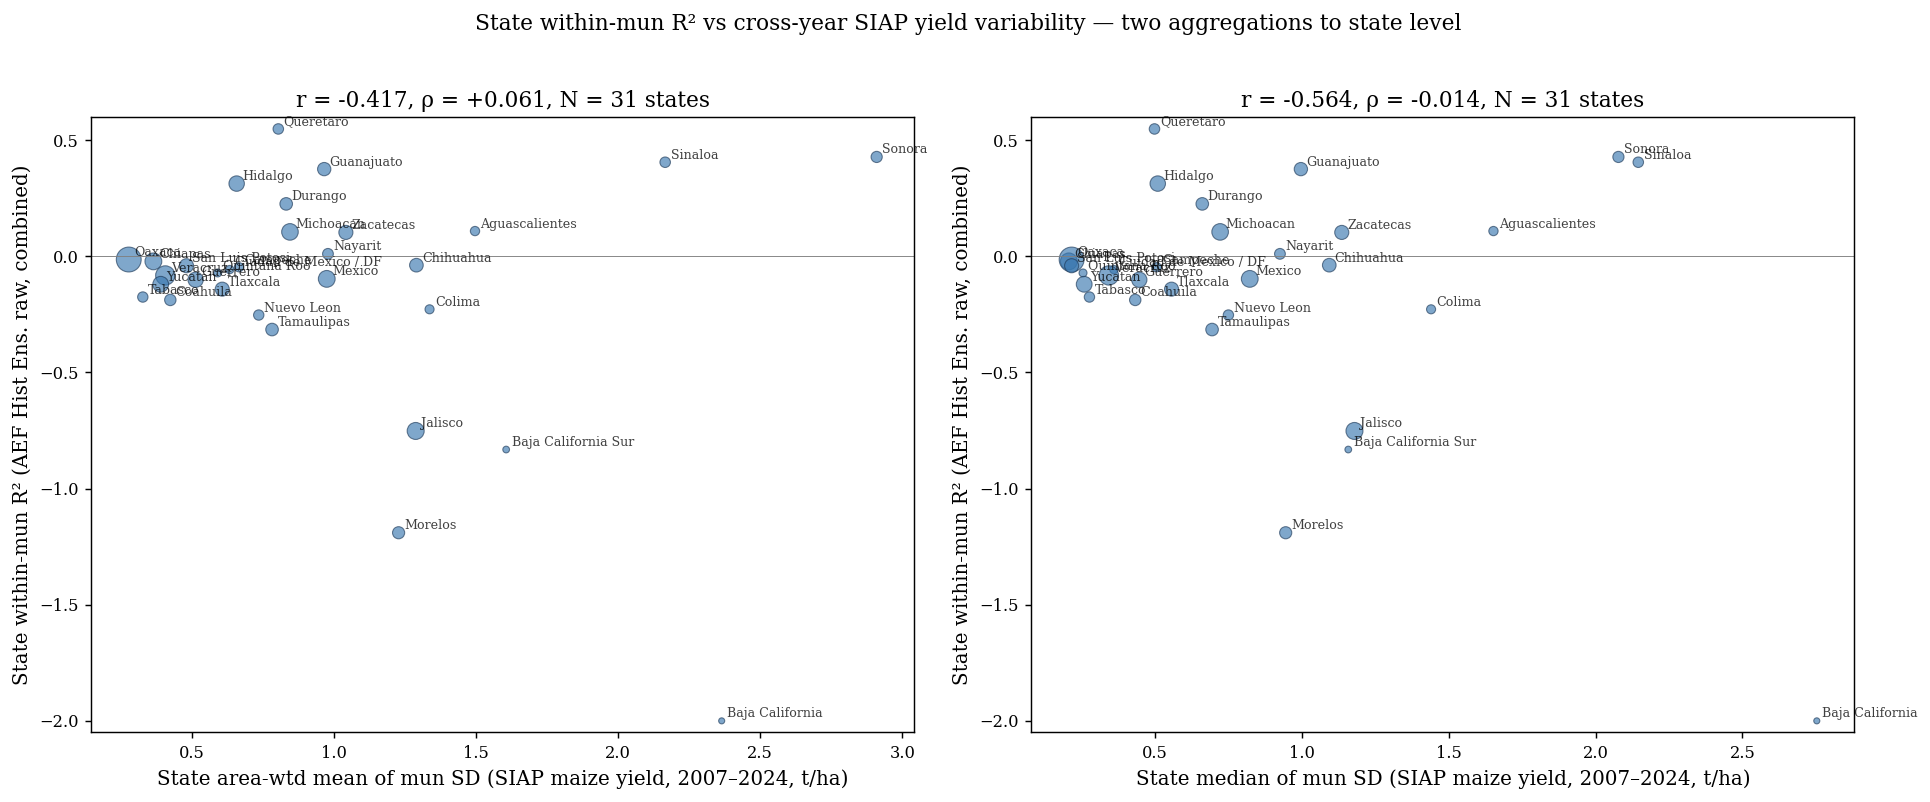

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_state_withinR2_vs_siapSD.png


In [2]:
# SIAP mun-year maize yield (combined): q / ha_planted, 2007–2024
siap = pd.read_stata(siap_ca07_dta, columns=["year","muncode","name","q","ha_planted"])
siap = siap[(siap["name"] == "Maize") & siap["year"].between(2007, 2024)].copy()
siap["yield"] = siap["q"] / siap["ha_planted"].replace(0, np.nan)
siap = siap.dropna(subset=["yield"])
siap["muncode"] = siap["muncode"].astype(str).str.zfill(5)
siap["state"]   = siap["muncode"].str[:2]
print(f"SIAP maize rows {len(siap):,}, muns {siap['muncode'].nunique():,}, yrs {siap['year'].min()}-{siap['year'].max()}")

# Per-mun SD and mean planted area (use only muns with >= 5 years)
mun_sd = (siap.groupby(["state","muncode"], as_index=False)
              .agg(sd_yield=("yield","std"),
                   mean_ha=("ha_planted","mean"),
                   n_yrs=("year","nunique")))
mun_sd = mun_sd[mun_sd["n_yrs"] >= 5].dropna(subset=["sd_yield","mean_ha"])
print(f"Per-mun SD: {len(mun_sd):,} muns")

# Two aggregations to state: (a) area-weighted mean of mun SDs, (b) median of mun SDs
def wmean(g, val, w):
    ww = g[w].fillna(0)
    if ww.sum() == 0: return np.nan
    return (g[val] * ww).sum() / ww.sum()
state_sd_w = (mun_sd.groupby("state")
                    .apply(lambda g: wmean(g, "sd_yield", "mean_ha"), include_groups=False)
                    .rename("state_sd_yield_wmean").reset_index())
state_sd_m = (mun_sd.groupby("state", as_index=False)["sd_yield"]
                    .median().rename(columns={"sd_yield":"state_sd_yield_med"}))
state_sd = state_sd_w.merge(state_sd_m, on="state")

# State within-R² from existing CSV (raw combined)
state_acc = pd.read_csv(state_acc_csv, dtype={"state":str})
state_acc["state"] = state_acc["state"].str.zfill(2)
sr = state_acc.query("season=='Combined' and model=='Raw'")[["state","state_name","N","n_mun","R2","Between_R2","Within_R2"]]

t1 = sr.merge(state_sd, on="state", how="inner")
print(f"Task 1 merged: {len(t1)} states")
print(t1[["state_name","state_sd_yield_wmean","state_sd_yield_med","Within_R2","n_mun"]]
        .sort_values("Within_R2", ascending=False).head(10))

# 2-panel scatter: (a) area-wtd mean SD, (b) median SD
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax_i, xcol, xlab in [(axes[0], "state_sd_yield_wmean", "State area-wtd mean of mun SD"),
                          (axes[1], "state_sd_yield_med",   "State median of mun SD")]:
    sizes = np.sqrt(t1["n_mun"].clip(lower=1)) * 8
    ax_i.scatter(t1[xcol], t1["Within_R2"].clip(lower=R2_CLIP_LO), s=sizes,
                  color="#3a78b0", alpha=0.65, edgecolor="#1f3b5a", linewidth=0.6)
    for _, r in t1.iterrows():
        ax_i.annotate(r["state_name"], (r[xcol], max(r["Within_R2"], R2_CLIP_LO)),
                      fontsize=7, alpha=0.75, xytext=(3, 2), textcoords="offset points")
    ax_i.axhline(0, color="grey", lw=0.5)
    rp = t1[[xcol,"Within_R2"]].corr().iloc[0,1]
    rs = t1[[xcol,"Within_R2"]].corr(method="spearman").iloc[0,1]
    ax_i.set_xlabel(f"{xlab} (SIAP maize yield, 2007–2024, t/ha)")
    ax_i.set_ylabel("State within-mun R² (AEF Hist Ens. raw, combined)")
    ax_i.set_title(f"r = {rp:+.3f}, ρ = {rs:+.3f}, N = {len(t1)} states")
    ax_i.set_ylim(R2_CLIP_LO - 0.05, max(0.55, t1['Within_R2'].max() + 0.05))
plt.suptitle("State within-mun R² vs cross-year SIAP yield variability — two aggregations to state level", y=1.02)
plt.tight_layout()
fig.savefig(fig_t1, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_t1}")

#### Task 2 — State-level total R² + total/within decomposition (raw AEF Hist Ens, combined)

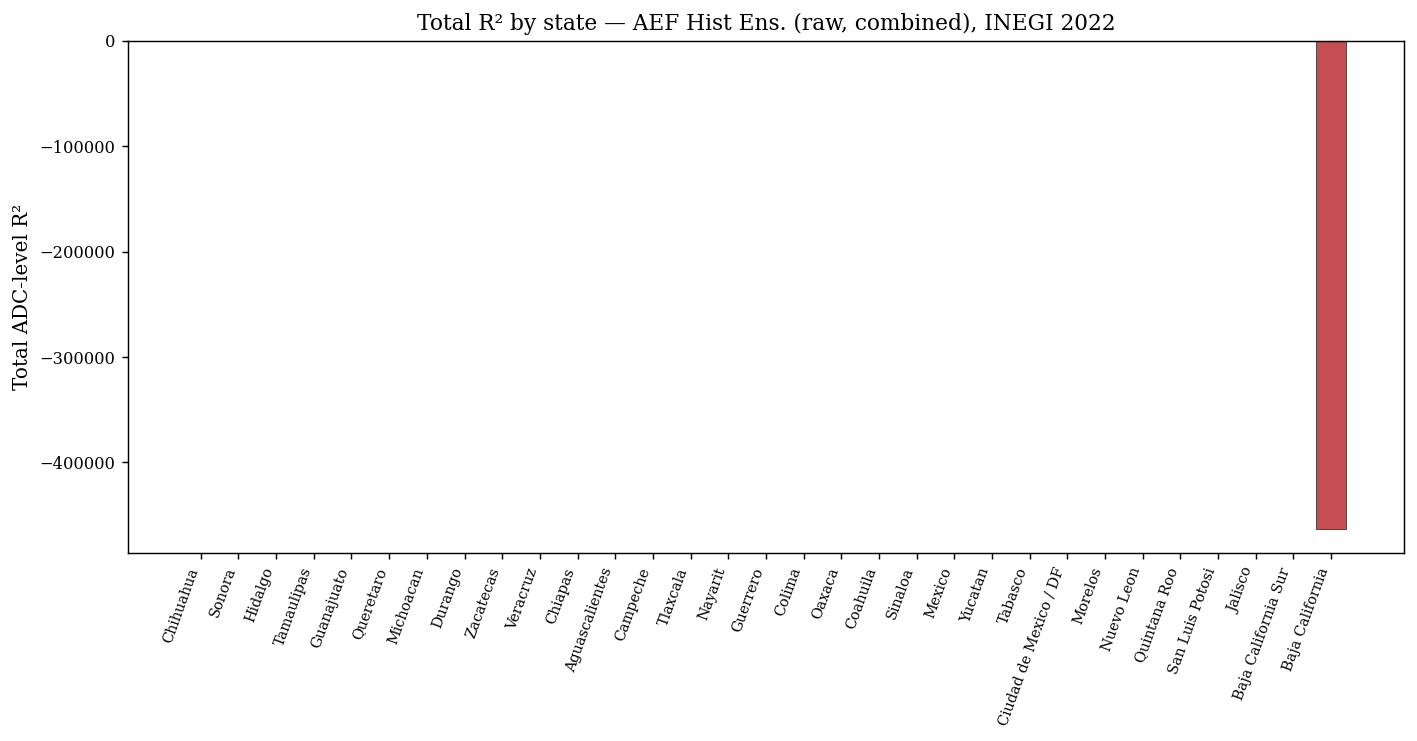

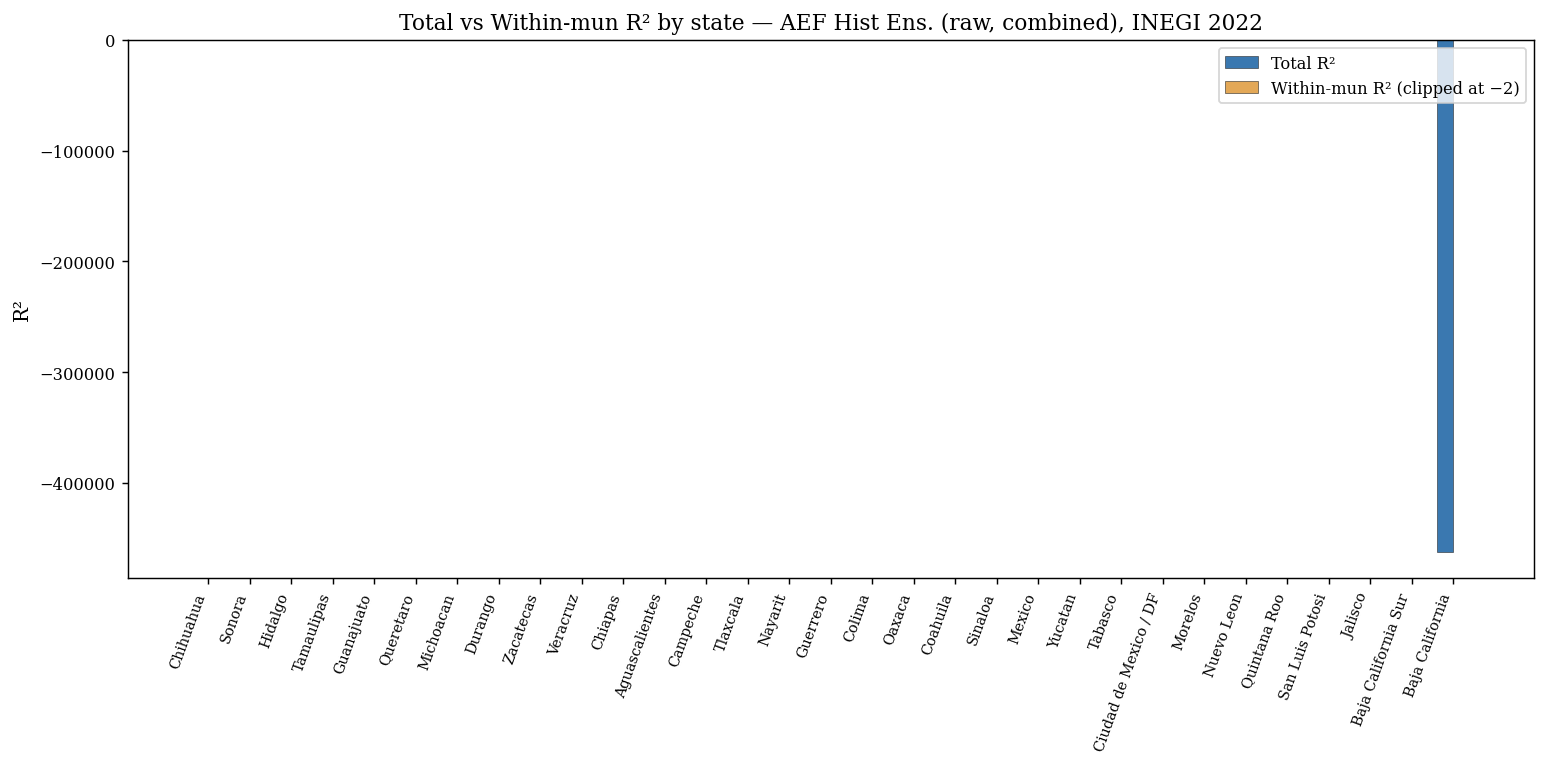

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_state_total_r2.png and /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_state_total_within_r2.png


In [3]:
# Use existing state_accuracy.csv (raw combined). It already has R2, Between_R2, Within_R2 per state.
sr2 = sr.copy().sort_values("R2", ascending=False).reset_index(drop=True)

# Plot 1: total R² by state (sorted)
fig, ax = plt.subplots(figsize=(11, 5.8))
colors = ["#3a78b0" if x >= 0 else "#c44e52" for x in sr2["R2"]]
ax.bar(np.arange(len(sr2)), sr2["R2"], color=colors, edgecolor="#222", linewidth=0.4)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xticks(np.arange(len(sr2)))
ax.set_xticklabels(sr2["state_name"], rotation=70, ha="right", fontsize=8)
ax.set_ylabel("Total ADC-level R²")
ax.set_title("Total R² by state — AEF Hist Ens. (raw, combined), INEGI 2022")
plt.tight_layout()
fig.savefig(fig_t2_total, bbox_inches="tight", dpi=170)
plt.show()

# Plot 2: total + within (grouped bars), sorted by total
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(sr2))
w = 0.4
ax.bar(x - w/2, sr2["R2"],         width=w, color="#3a78b0", label="Total R²", edgecolor="#222", linewidth=0.3)
ax.bar(x + w/2, sr2["Within_R2"].clip(lower=R2_CLIP_LO), width=w, color="#e3a857", label="Within-mun R² (clipped at −2)", edgecolor="#222", linewidth=0.3)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(sr2["state_name"], rotation=70, ha="right", fontsize=8)
ax.set_ylabel("R²")
ax.set_title("Total vs Within-mun R² by state — AEF Hist Ens. (raw, combined), INEGI 2022")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(fig_t2_decomp, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_t2_total} and {fig_t2_decomp}")

#### Task 3 — Within-mun R² by exemplar muns binned by mean maize parcel size (INEGI 2022)

Mean maize parcel size per mun = sum(land_input) / sum(num_up) across the mun's ADCs (maize UPs only).

Task 3: 1,855 muns; parcel size median = 1.54 ha
   qbin  med_parcel   med_wr2  mean_wr2_wins    n
0     0    0.668300 -0.155635      -0.473203  371
1     1    1.085997 -0.116033      -0.361212  371
2     2    1.538098 -0.154118      -0.437767  371
3     3    2.279308 -0.128487      -0.411011  371
4     4    4.447010 -0.143379      -0.427397  371


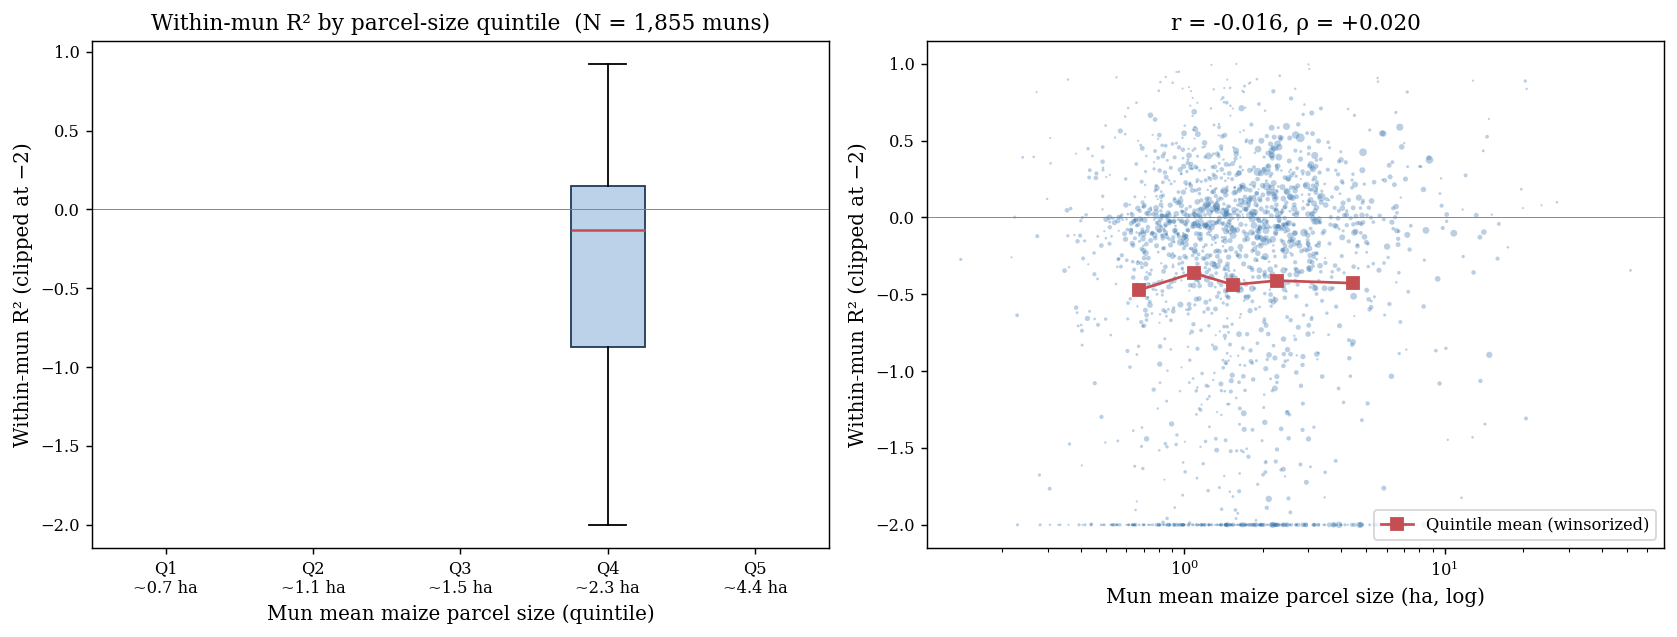

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_parcelsize_binned_within_r2.png


In [4]:
# Mun-mean parcel size from INEGI 2022
inegi = pd.read_stata(inegi_2022_dta, columns=["muncode","adc","num_up","land_input","yield"])
inegi["muncode"] = inegi["muncode"].astype(str).str.zfill(5)
mun_psize = (inegi.groupby("muncode", as_index=False)
                    .agg(tot_land=("land_input","sum"),
                         tot_up=("num_up","sum"),
                         n_adc=("adc","nunique")))
mun_psize["mean_parcel_ha"] = mun_psize["tot_land"] / mun_psize["tot_up"].replace(0, np.nan)
mun_psize = mun_psize.dropna(subset=["mean_parcel_ha"])
mun_psize = mun_psize[mun_psize["mean_parcel_ha"] > 0]

mun_r2 = pd.read_csv(mun_r2_csv, dtype={"muncode":str})
mun_r2["muncode"] = mun_r2["muncode"].str.zfill(5)
t3 = mun_r2.merge(mun_psize, on="muncode", how="inner")
t3["log_parcel"] = np.log10(t3["mean_parcel_ha"].clip(lower=0.01))
t3["wr2_wins"]   = t3["within_r2"].clip(lower=R2_CLIP_LO, upper=1)
print(f"Task 3: {len(t3):,} muns; parcel size median = {t3['mean_parcel_ha'].median():.2f} ha")

# Bin into quintiles by mean_parcel_ha
t3["qbin"] = pd.qcut(t3["mean_parcel_ha"], q=5, labels=False)
qstats = (t3.groupby("qbin")
             .agg(med_parcel=("mean_parcel_ha","median"),
                  med_wr2=("within_r2","median"),
                  mean_wr2_wins=("wr2_wins","mean"),
                  n=("within_r2","size"))
             .reset_index())
print(qstats)

# Pearson / Spearman corr
rp = t3[["log_parcel","wr2_wins"]].corr().iloc[0,1]
rs = t3[["log_parcel","within_r2"]].corr(method="spearman").iloc[0,1]

# Plot: 1) box per quintile, 2) scatter overlaid
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# (a) box per quintile
data = [t3.loc[t3["qbin"]==q, "wr2_wins"].values for q in range(5)]
bp = ax[0].boxplot(data, showfliers=False, patch_artist=True,
                     boxprops=dict(facecolor="#bcd2e8", edgecolor="#1f3b5a"),
                     medianprops=dict(color="#c44e52", lw=1.4))
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set_xticks(np.arange(1, 6))
ax[0].set_xticklabels([f"Q{q+1}\n~{qstats.loc[q,'med_parcel']:.1f} ha" for q in range(5)], fontsize=9)
ax[0].set_xlabel("Mun mean maize parcel size (quintile)")
ax[0].set_ylabel("Within-mun R² (clipped at −2)")
ax[0].set_title(f"Within-mun R² by parcel-size quintile  (N = {len(t3):,} muns)")
# (b) scatter on log axis
ax[1].scatter(t3["mean_parcel_ha"], t3["wr2_wins"], s=np.sqrt(t3["n_rows"])*1.0,
                alpha=0.35, color="#3a78b0", edgecolor="none", rasterized=True)
ax[1].plot(qstats["med_parcel"], qstats["mean_wr2_wins"], "s-", color="#c44e52", lw=1.5, ms=7, label="Quintile mean (winsorized)")
ax[1].axhline(0, color="grey", lw=0.5)
ax[1].set_xscale("log")
ax[1].set_xlabel("Mun mean maize parcel size (ha, log)")
ax[1].set_ylabel("Within-mun R² (clipped at −2)")
ax[1].set_title(f"r = {rp:+.3f}, ρ = {rs:+.3f}")
ax[1].legend(loc="lower right")
plt.tight_layout()
fig.savefig(fig_t3_binned, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_t3_binned}")

      kind tercile muncode  mean_parcel_ha  within_r2  n_rows
0  Typical   Small   30024        0.926834  -0.082756      38
1     Best   Small   13015        1.092560   0.687572     102
2  Typical     Mid   04004        2.237121  -0.059802      99
3     Best     Mid   22012        2.199526   0.820992      32
4  Typical   Large   30129        3.402938  -0.102830      31
5     Best   Large   08012        2.571992   0.774259      33


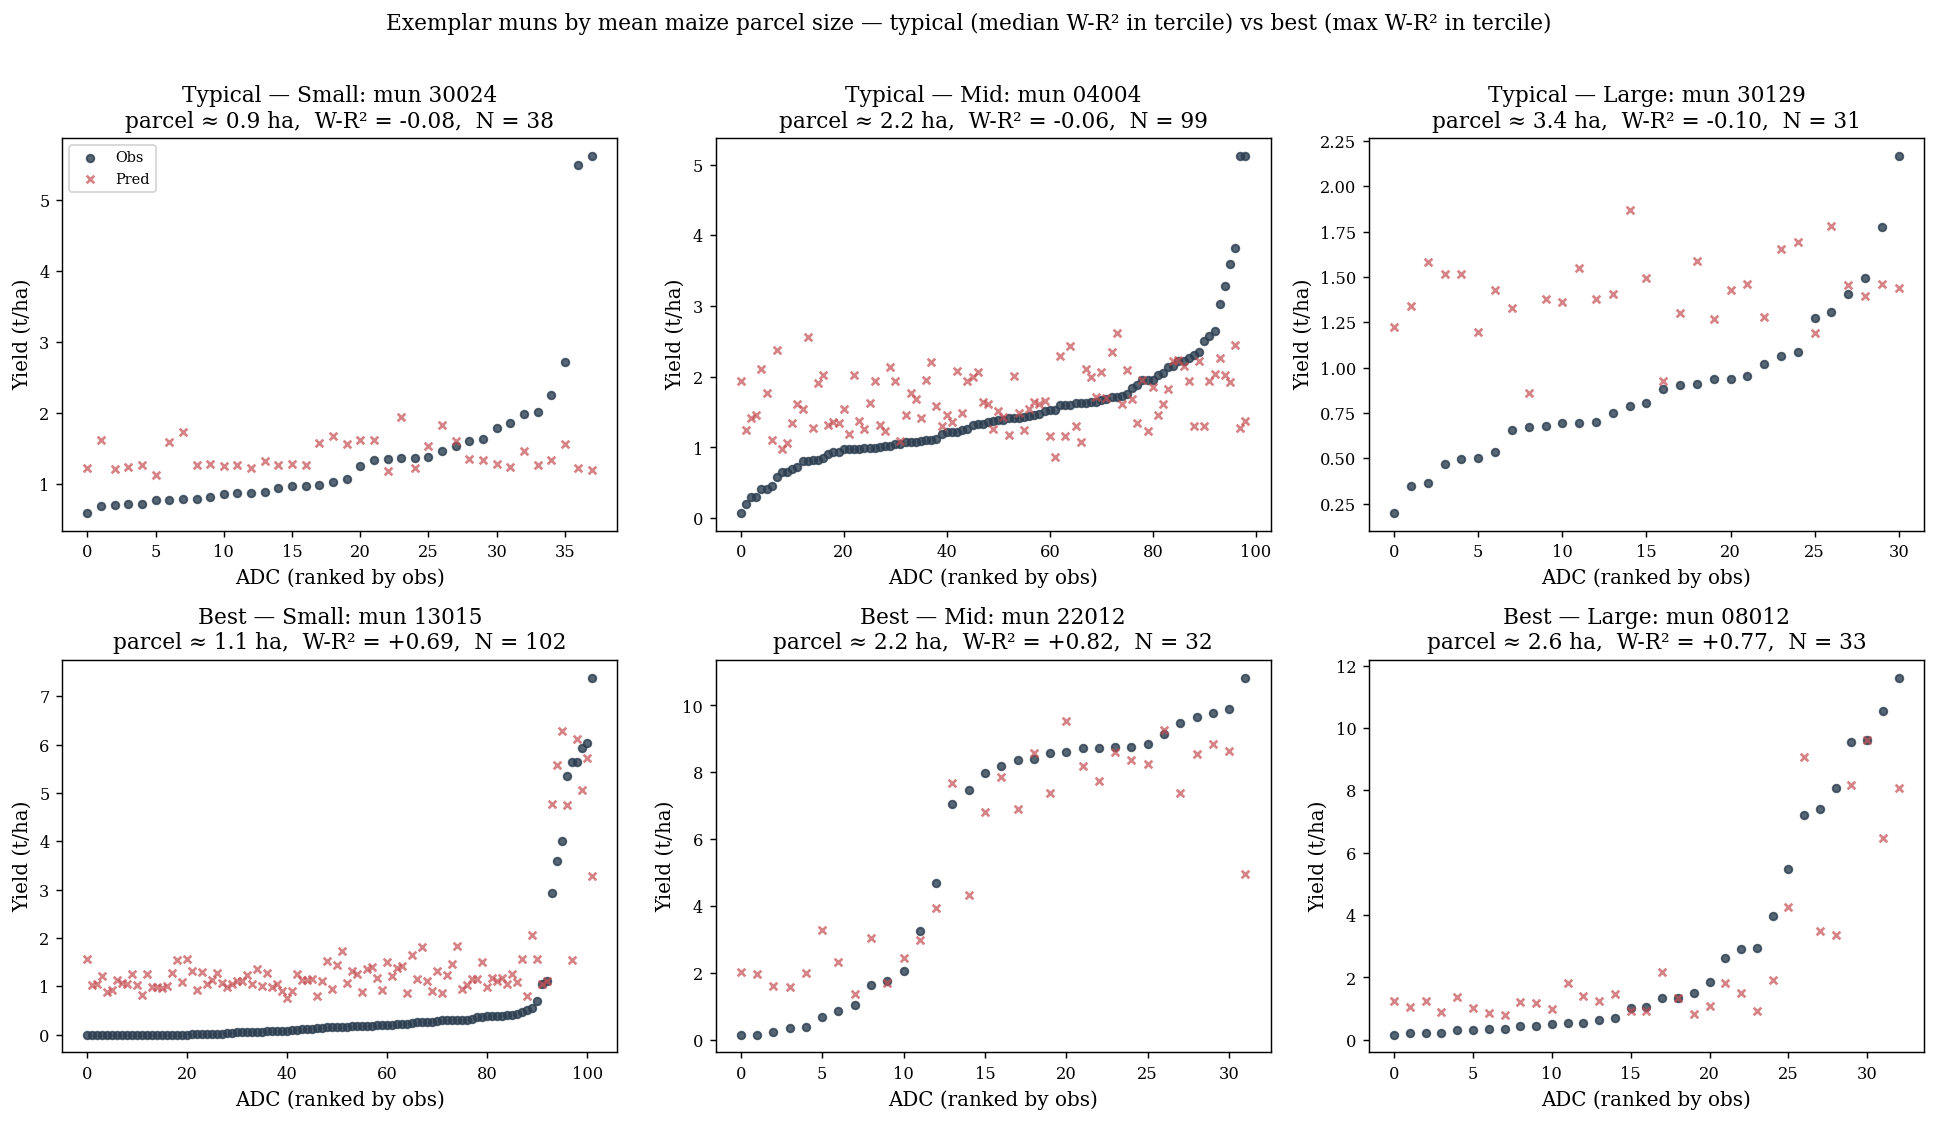

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_parcelsize_exemplar_muns.png


In [5]:
# Exemplar muns by parcel-size tercile: show both a "typical" (median W-R²) and a "best" (top W-R²)
#  - n_rows >= 20 so the obs-vs-pred panel has texture
t3_big = t3[t3["n_rows"] >= 20].copy()
t3_big["tercile"] = pd.qcut(t3_big["mean_parcel_ha"], q=3, labels=["Small","Mid","Large"])

exempl_rows = []
for terc in ["Small","Mid","Large"]:
    sub = t3_big[t3_big["tercile"] == terc].copy()
    # typical = mun closest to tercile median W-R²
    tmed = sub["within_r2"].median()
    sub["d_med"] = (sub["within_r2"] - tmed).abs()
    typical = sub.sort_values("d_med").iloc[0]
    # best = top within-R² (still in this tercile)
    best = sub.sort_values("within_r2", ascending=False).iloc[0]
    exempl_rows.append({**typical.to_dict(), "kind":"Typical"})
    exempl_rows.append({**best.to_dict(),    "kind":"Best"})
exempl = pd.DataFrame(exempl_rows)
print(exempl[["kind","tercile","muncode","mean_parcel_ha","within_r2","n_rows"]])

# 2 × 3 panel: rows = {Typical, Best}, cols = {Small, Mid, Large}
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for r_i, kind in enumerate(["Typical","Best"]):
    for c_i, terc in enumerate(["Small","Mid","Large"]):
        ax_i = axes[r_i, c_i]
        m = exempl[(exempl["kind"]==kind) & (exempl["tercile"]==terc)].iloc[0]
        sub = df_eval[df_eval["muncode"] == m["muncode"]].dropna(subset=["yield","pred"]).copy()
        sub = sub.sort_values("yield").reset_index(drop=True)
        x = np.arange(len(sub))
        ax_i.scatter(x, sub["yield"], s=18, color="#2c3e50", label="Obs", alpha=0.8)
        ax_i.scatter(x, sub["pred"],  s=18, color="#c44e52", label="Pred", alpha=0.7, marker="x")
        ax_i.set_xlabel("ADC (ranked by obs)")
        ax_i.set_ylabel("Yield (t/ha)")
        ax_i.set_title(f"{kind} — {terc}: mun {m['muncode']}\n"
                       f"parcel ≈ {m['mean_parcel_ha']:.1f} ha,  W-R² = {m['within_r2']:+.2f},  N = {len(sub)}")
        if r_i == 0 and c_i == 0:
            ax_i.legend(loc="best", fontsize=8)
plt.suptitle("Exemplar muns by mean maize parcel size — typical (median W-R² in tercile) vs best (max W-R² in tercile)",
              y=1.01)
plt.tight_layout()
fig.savefig(fig_t3_exempl, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_t3_exempl}")

#### Task 4 — Placebo muns: contiguous random ADC groupings preserving the per-state mun-size distribution

For each state, build the ADC adjacency graph from `adc_shapefile.shp`, then region-grow contiguous groups whose sizes match the empirical distribution of (real) mun sizes in that state. Repeat N times; recompute pooled within-mun R² for each placebo and compare to the actual value (0.152 combined raw).

Implementation notes:
- adjacency = touches() between ADC polygons within the same state
- region-grow: shuffle ADCs, pick the first unassigned as a seed, BFS until target size reached, then move to next seed
- if a seed has fewer reachable neighbors than the target size, take what's available (preserves contiguity over exact size match)
- placebo "muncode" = state code + 3-digit cluster index
- compute pooled within-R² across all states using the same `within_r2(...)` function as the paper

In [6]:
# Load ADC shapefile, build per-state adjacency once (slow step — cache the result)
import pickle
from collections import defaultdict, deque

adj_cache = os.path.join(out_dir, "placebo_adc_adjacency.pkl")

if os.path.exists(adj_cache):
    with open(adj_cache, "rb") as f:
        adj_per_state, adc_state_map = pickle.load(f)
    print(f"Loaded cached adjacency for {len(adj_per_state)} states")
else:
    print("Building ADC adjacency (this takes a few minutes)...")
    gdf = gpd.read_file(adc_shp)
    id_candidates = [c for c in gdf.columns if c.lower() in ("adc","adcid","cve_amc","id_adc")]
    print("adc id candidates:", id_candidates, "; geom rows:", len(gdf))
    if id_candidates:
        gdf = gdf.rename(columns={id_candidates[0]: "adc"})
    else:
        raise RuntimeError("could not find ADC id column in shapefile; cols=" + ",".join(gdf.columns))
    # shapefile adcid format = '01001106-8001' (with dash); eval uses '010011068001' (no dash)
    gdf["adc"] = gdf["adc"].astype(str).str.replace("-", "", regex=False)
    eval_adcs = set(df_eval["adc"].astype(str))
    gdf = gdf[gdf["adc"].isin(eval_adcs)].copy()
    print(f"  filtered to {len(gdf):,} ADCs that appear in eval frame (before dissolve)")
    # dissolve duplicates (some adcs may be split across multiple shapefile rows)
    gdf = gdf.dissolve(by="adc", as_index=False)
    gdf["state"] = gdf["adc"].str[:2]
    print(f"  after dissolve: {len(gdf):,} unique ADC polygons")

    adj_per_state = {}
    adc_state_map = {}
    for st, sub in gdf.groupby("state"):
        sub = sub.reset_index(drop=True)
        sjoin = gpd.sjoin(sub[["adc","geometry"]], sub[["adc","geometry"]], how="inner", predicate="touches")
        adj = defaultdict(set)
        for a, b in zip(sjoin["adc_left"], sjoin["adc_right"]):
            if a != b:
                adj[a].add(b)
        for a in sub["adc"]:
            adj.setdefault(a, set())
        adj_per_state[st] = {k: list(v) for k, v in adj.items()}
        for a in sub["adc"]:
            adc_state_map[a] = st
        print(f"  state {st}: {len(sub)} ADCs, mean degree {np.mean([len(v) for v in adj.values()]):.2f}")
    with open(adj_cache, "wb") as f:
        pickle.dump((adj_per_state, adc_state_map), f)
    print(f"Cached to {adj_cache}")

Loaded cached adjacency for 31 states


In [7]:
# Build per-state real mun-size distribution from df_eval (so target sizes match what the model actually saw)
state_mun_sizes = {}
for st, sub in df_eval.groupby("state"):
    sizes = sub.groupby("muncode").size().tolist()  # rows per mun (not unique ADCs, but eval-frame rows)
    state_mun_sizes[st] = sizes
print({k: (len(v), sum(v)) for k, v in list(state_mun_sizes.items())[:5]})

{'01': (11, 803), '02': (2, 60), '03': (3, 98), '04': (11, 1127), '05': (25, 554)}


In [8]:
# Placebo construction: contiguous random groupings via BFS region-growing.
# Operate on the eval-frame ADC list directly (rows, not unique ADCs) so target sizes match.
rng_global = np.random.default_rng(20260526)

def build_placebo_assignment(rng, st, eval_sub, adj):
    """Return Series indexed like eval_sub.index, value = placebo cluster id.
    Groups ADCs in eval_sub contiguously into clusters that approximately match
    the real mun-size distribution (in terms of eval-frame row counts)."""
    # work at unique-ADC level; map rows->adc->cluster later
    adcs = eval_sub["adc"].astype(str).unique().tolist()
    adc_set = set(adcs)
    # restrict adjacency to ADCs in this eval subset
    adj_local = {a: [n for n in adj.get(a, []) if n in adc_set] for a in adcs}
    # rows per adc (so size targets reflect row counts, not adc counts)
    rows_per_adc = eval_sub.groupby("adc").size().to_dict()

    # target cluster sizes (in rows), sorted desc so big clusters get priority on seeds
    targets = sorted(state_mun_sizes[st], reverse=True)

    unassigned = set(adcs)
    cluster_of = {}
    cid = 0
    for tgt in targets:
        if not unassigned:
            break
        # seed from unassigned
        seed = rng.choice(list(unassigned))
        # BFS until row-count reaches tgt OR we exhaust connected component
        q = deque([seed])
        taken = []
        taken_set = set()
        rows = 0
        while q and rows < tgt:
            v = q.popleft()
            if v in taken_set or v not in unassigned:
                continue
            taken.append(v)
            taken_set.add(v)
            rows += rows_per_adc.get(v, 0)
            # shuffle neighbors for randomness
            nbrs = [n for n in adj_local.get(v, []) if n in unassigned and n not in taken_set]
            rng.shuffle(nbrs)
            q.extend(nbrs)
        for a in taken:
            cluster_of[a] = cid
            unassigned.discard(a)
        cid += 1
    # any ADCs still unassigned (isolated components): give each its own cluster
    for a in list(unassigned):
        cluster_of[a] = cid
        cid += 1

    return eval_sub["adc"].astype(str).map(cluster_of)

def run_placebo(seed, eval_df):
    rng = np.random.default_rng(seed)
    placebo_codes = pd.Series(index=eval_df.index, dtype=object)
    for st in eval_df["state"].unique():
        sub = eval_df[eval_df["state"] == st]
        adj = adj_per_state.get(st, {})
        clust = build_placebo_assignment(rng, st, sub, adj)
        placebo_codes.loc[sub.index] = st + clust.astype(str).str.zfill(4)
    tmp = eval_df[["yield","pred"]].copy()
    tmp["placebo_mun"] = placebo_codes
    return within_r2(tmp, "yield", "pred", gc="placebo_mun")

# Sanity: real within-R² (should match 0.152)
real_wr2 = within_r2(df_eval, "yield", "pred", "muncode")
print(f"Real within-R² (raw combined): {real_wr2:.4f}")

# Quick test: 1 placebo
test_wr2 = run_placebo(42, df_eval)
print(f"Test placebo within-R² (seed=42): {test_wr2:.4f}")

Real within-R² (raw combined): 0.1521


Test placebo within-R² (seed=42): 0.1965


In [9]:
# Run the contiguous-grouping placebo (200 reps)
N_REPS = 200
import time
rows = []
t0 = time.time()
for i in range(N_REPS):
    wr = run_placebo(1000 + i, df_eval)
    rows.append({"rep": i, "seed": 1000+i, "within_r2": wr, "kind":"contiguous"})
    if (i+1) % 25 == 0:
        elapsed = time.time() - t0
        mean_so_far = np.mean([r['within_r2'] for r in rows])
        print(f"  contig rep {i+1}/{N_REPS}  elapsed {elapsed/60:.1f} min  mean placebo W-R² {mean_so_far:+.4f}")
placebo_contig = pd.DataFrame(rows)
print(placebo_contig.describe())

  contig rep 25/200  elapsed 0.2 min  mean placebo W-R² +0.1849


  contig rep 50/200  elapsed 0.5 min  mean placebo W-R² +0.1838


  contig rep 75/200  elapsed 0.7 min  mean placebo W-R² +0.1879


  contig rep 100/200  elapsed 0.9 min  mean placebo W-R² +0.1864


  contig rep 125/200  elapsed 1.2 min  mean placebo W-R² +0.1857


  contig rep 150/200  elapsed 1.4 min  mean placebo W-R² +0.1864


  contig rep 175/200  elapsed 1.6 min  mean placebo W-R² +0.1870


  contig rep 200/200  elapsed 1.8 min  mean placebo W-R² +0.1872
              rep         seed   within_r2
count  200.000000   200.000000  200.000000
mean    99.500000  1099.500000    0.187172
std     57.879185    57.879185    0.024164
min      0.000000  1000.000000    0.130019
25%     49.750000  1049.750000    0.171152
50%     99.500000  1099.500000    0.187930
75%    149.250000  1149.250000    0.204139
max    199.000000  1199.000000    0.249049


In [10]:
# Label-permutation placebo: within each state, permute mun labels among ADCs (preserves mun-size by construction,
# but destroys spatial structure entirely — pure label-shuffle baseline)
N_PERM = 100
perm_rows = []
t0 = time.time()
for i in range(N_PERM):
    rng = np.random.default_rng(50000 + i)
    permuted = df_eval[["yield","pred","state","muncode"]].copy()
    # group rows by state, shuffle mun-row indices within state
    new_codes = permuted["muncode"].to_numpy().copy()
    for st in permuted["state"].unique():
        mask = (permuted["state"] == st).to_numpy()
        idx = np.where(mask)[0]
        shuffled = rng.permutation(idx)
        new_codes[idx] = new_codes[shuffled]
    permuted["perm_mun"] = new_codes
    wr = within_r2(permuted, "yield", "pred", gc="perm_mun")
    perm_rows.append({"rep":i, "seed":50000+i, "within_r2":wr, "kind":"permutation"})
    if (i+1) % 25 == 0:
        elapsed = time.time() - t0
        mean_so_far = np.mean([r['within_r2'] for r in perm_rows])
        print(f"  perm rep {i+1}/{N_PERM}  elapsed {elapsed/60:.1f} min  mean placebo W-R² {mean_so_far:+.4f}")
placebo_perm = pd.DataFrame(perm_rows)
print(placebo_perm.describe())

# Combine and persist both placebo types
placebo_df = pd.concat([placebo_contig, placebo_perm], ignore_index=True)
placebo_df.to_csv(placebo_csv, index=False)
print(f"Saved combined {placebo_csv}  ({len(placebo_df)} rows: "
      f"{(placebo_df['kind']=='contiguous').sum()} contiguous + {(placebo_df['kind']=='permutation').sum()} permutation)")

  perm rep 25/100  elapsed 0.0 min  mean placebo W-R² +0.4559


  perm rep 50/100  elapsed 0.0 min  mean placebo W-R² +0.4559


  perm rep 75/100  elapsed 0.0 min  mean placebo W-R² +0.4559


  perm rep 100/100  elapsed 0.1 min  mean placebo W-R² +0.4559
              rep          seed   within_r2
count  100.000000    100.000000  100.000000
mean    49.500000  50049.500000    0.455879
std     29.011492     29.011492    0.000541
min      0.000000  50000.000000    0.454334
25%     24.750000  50024.750000    0.455509
50%     49.500000  50049.500000    0.455860
75%     74.250000  50074.250000    0.456265
max     99.000000  50099.000000    0.457064
Saved combined /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/placebo_within_r2.csv  (300 rows: 200 contiguous + 100 permutation)


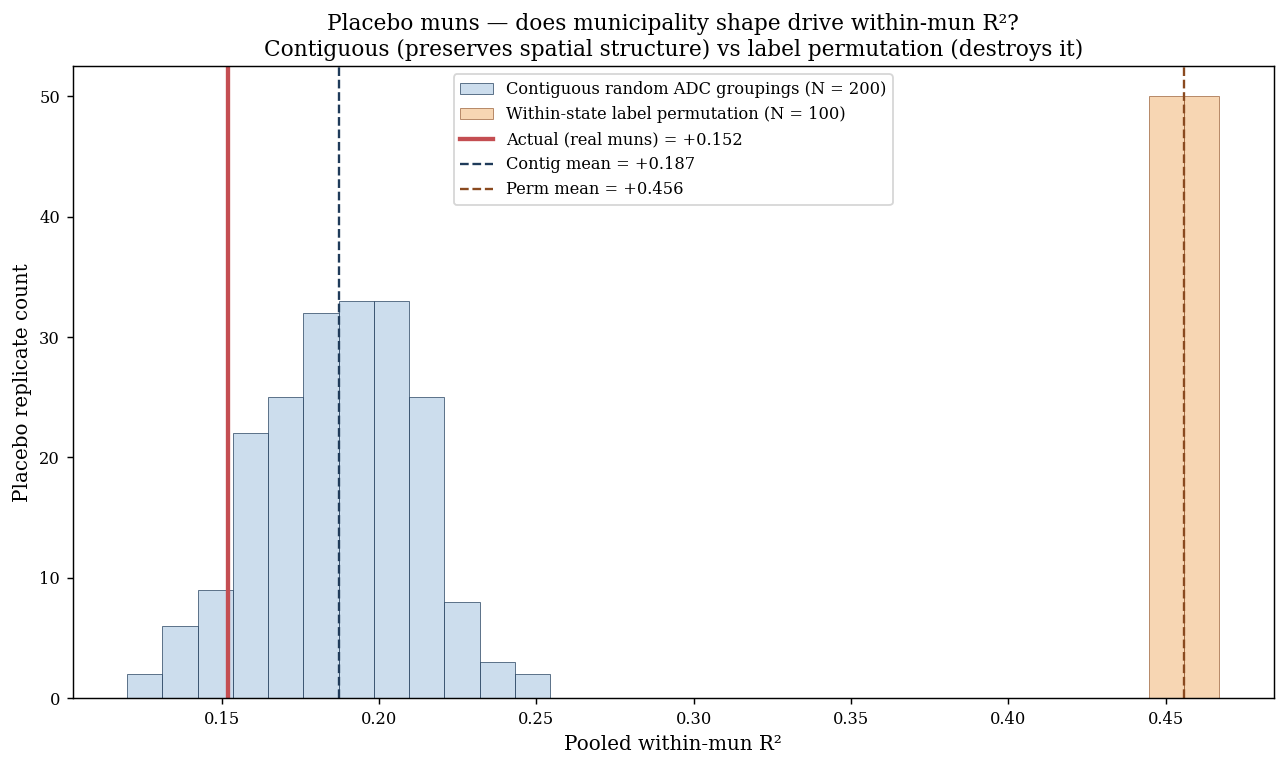

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_placebo_within_r2_hist.png

Real W-R²       : +0.1521
Contig placebos : mean +0.1872  sd +0.0241  frac ≥ real 0.915
Perm  placebos  : mean +0.4559  sd +0.0005  frac ≥ real 1.000


In [11]:
# Histogram overlaying both placebo types vs the actual within-mun R²
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(min(placebo_df["within_r2"].min(), real_wr2) - 0.01,
                   max(placebo_df["within_r2"].max(), real_wr2) + 0.01, 32)

c_vals = placebo_contig["within_r2"].values
p_vals = placebo_perm["within_r2"].values

ax.hist(c_vals, bins=bins, color="#bcd2e8", edgecolor="#1f3b5a", linewidth=0.5,
        alpha=0.75, label=f"Contiguous random ADC groupings (N = {len(c_vals)})")
ax.hist(p_vals, bins=bins, color="#f4c08a", edgecolor="#8a4a1f", linewidth=0.5,
        alpha=0.65, label=f"Within-state label permutation (N = {len(p_vals)})")

ax.axvline(real_wr2, color="#c44e52", lw=2.4, label=f"Actual (real muns) = {real_wr2:+.3f}")
ax.axvline(c_vals.mean(), color="#1f3b5a", lw=1.3, linestyle="--",
            label=f"Contig mean = {c_vals.mean():+.3f}")
ax.axvline(p_vals.mean(), color="#8a4a1f", lw=1.3, linestyle="--",
            label=f"Perm mean = {p_vals.mean():+.3f}")

ax.set_xlabel("Pooled within-mun R²")
ax.set_ylabel("Placebo replicate count")
ax.set_title("Placebo muns — does municipality shape drive within-mun R²?\n"
              "Contiguous (preserves spatial structure) vs label permutation (destroys it)")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(fig_t4_hist, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_t4_hist}")

# Tail probabilities
print(f"\nReal W-R²       : {real_wr2:+.4f}")
print(f"Contig placebos : mean {c_vals.mean():+.4f}  sd {c_vals.std():+.4f}  "
        f"frac ≥ real {(c_vals >= real_wr2).mean():.3f}")
print(f"Perm  placebos  : mean {p_vals.mean():+.4f}  sd {p_vals.std():+.4f}  "
        f"frac ≥ real {(p_vals >= real_wr2).mean():.3f}")

#### Extension A — Variance-compression decomposition across partitions

For each partition (real, contiguous placebo, label permutation), decompose the pooled within-partition stats:
`SD(obs)_within`, `SD(pred)_within`, compression ratio `SD(pred)/SD(obs)`, pooled within-group Pearson correlation, and within-R². The variance-compression mechanic predicts:

`within-R² ≈ 2 ρ (SD_pred/SD_obs) − (SD_pred/SD_obs)²`

so a small `SD_pred/SD_obs` mechanically caps within-R² regardless of model skill. Comparing partition types should show that the ratio (and the resulting W-R²) is dominated by within-group obs variance, not by anything the model learned.

In [12]:
# Decompose pooled within-partition stats for: real muns, contig placebo, perm placebo.
# Repeat 30 reps each for placebos; capture SDs / correlation / W-R² per replicate.

def within_stats(df, y, p, gc):
    """Return pooled within-group stats: sd_obs, sd_pred, rho, within_r2."""
    s = df[[y, p, gc]].replace([np.inf,-np.inf], np.nan).dropna().copy()
    cnt = s.groupby(gc).size()
    s = s[s[gc].isin(cnt[cnt >= MIN_ADCS_FOR_R2].index)]
    if len(s) == 0:
        return dict(sd_obs=np.nan, sd_pred=np.nan, rho=np.nan, within_r2=np.nan, n=0)
    gm = s.groupby(gc)[[y, p]].transform("mean")
    dy = s[y] - gm[y]
    dp = s[p] - gm[p]
    sd_o = dy.std(ddof=0)
    sd_p = dp.std(ddof=0)
    rho = (dy * dp).mean() / (sd_o * sd_p) if (sd_o > 0 and sd_p > 0) else np.nan
    wr  = 1 - ((dy - dp)**2).sum() / (dy**2).sum() if (dy**2).sum() > 0 else np.nan
    return dict(sd_obs=sd_o, sd_pred=sd_p, ratio=sd_p/sd_o if sd_o>0 else np.nan,
                rho=rho, within_r2=wr, n=len(s))

# Real partition
real_stats = within_stats(df_eval, "yield", "pred", "muncode")
print("Real muns:", real_stats)

# Sample 30 contiguous placebos for stats
N_SAMP = 30
contig_stats = []
for i in range(N_SAMP):
    rng = np.random.default_rng(20000 + i)
    placebo_codes = pd.Series(index=df_eval.index, dtype=object)
    for st in df_eval["state"].unique():
        sub = df_eval[df_eval["state"] == st]
        clust = build_placebo_assignment(rng, st, sub, adj_per_state.get(st, {}))
        placebo_codes.loc[sub.index] = st + clust.astype(str).str.zfill(4)
    tmp = df_eval[["yield","pred"]].copy()
    tmp["placebo_mun"] = placebo_codes
    contig_stats.append(within_stats(tmp, "yield", "pred", "placebo_mun"))
    if (i+1) % 10 == 0:
        print(f"  contig stats rep {i+1}/{N_SAMP}")
contig_stats = pd.DataFrame(contig_stats)

# Sample 30 perm placebos for stats
perm_stats = []
for i in range(N_SAMP):
    rng = np.random.default_rng(60000 + i)
    permuted = df_eval[["yield","pred","state","muncode"]].copy()
    new_codes = permuted["muncode"].to_numpy().copy()
    for st in permuted["state"].unique():
        mask = (permuted["state"] == st).to_numpy()
        idx = np.where(mask)[0]
        shuffled = rng.permutation(idx)
        new_codes[idx] = new_codes[shuffled]
    permuted["perm_mun"] = new_codes
    perm_stats.append(within_stats(permuted, "yield", "pred", "perm_mun"))
perm_stats = pd.DataFrame(perm_stats)

summary = pd.DataFrame([
    {"partition":"Real muns",        **real_stats},
    {"partition":"Contig placebo",   **{k: contig_stats[k].mean() for k in ["sd_obs","sd_pred","ratio","rho","within_r2"]}, "n":int(contig_stats["n"].mean())},
    {"partition":"Perm placebo",     **{k: perm_stats[k].mean()   for k in ["sd_obs","sd_pred","ratio","rho","within_r2"]}, "n":int(perm_stats["n"].mean())},
])
summary["pred_wr2"] = 2 * summary["rho"] * summary["ratio"] - summary["ratio"]**2  # mechanical prediction
print("\nPooled within-partition decomposition (raw predictions):")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

summary.to_csv(os.path.join(out_dir, "variance_compression_by_partition.csv"), index=False)

Real muns: {'sd_obs': np.float32(1.4293195), 'sd_pred': np.float64(1.0153701676421982), 'ratio': np.float64(0.7103871226736916), 'rho': np.float64(0.4622493131577503), 'within_r2': np.float64(0.1521020752243486), 'n': 72376}


  contig stats rep 10/30


  contig stats rep 20/30


  contig stats rep 30/30



Pooled within-partition decomposition (raw predictions):
     partition  sd_obs  sd_pred  ratio    rho  within_r2     n  pred_wr2
     Real muns  1.4293   1.0154 0.7104 0.4622     0.1521 72376    0.1521
Contig placebo  1.4241   0.9933 0.6977 0.4809     0.1840 51000    0.1843
  Perm placebo  2.0841   1.4279 0.6852 0.6752     0.4558 72400    0.4558


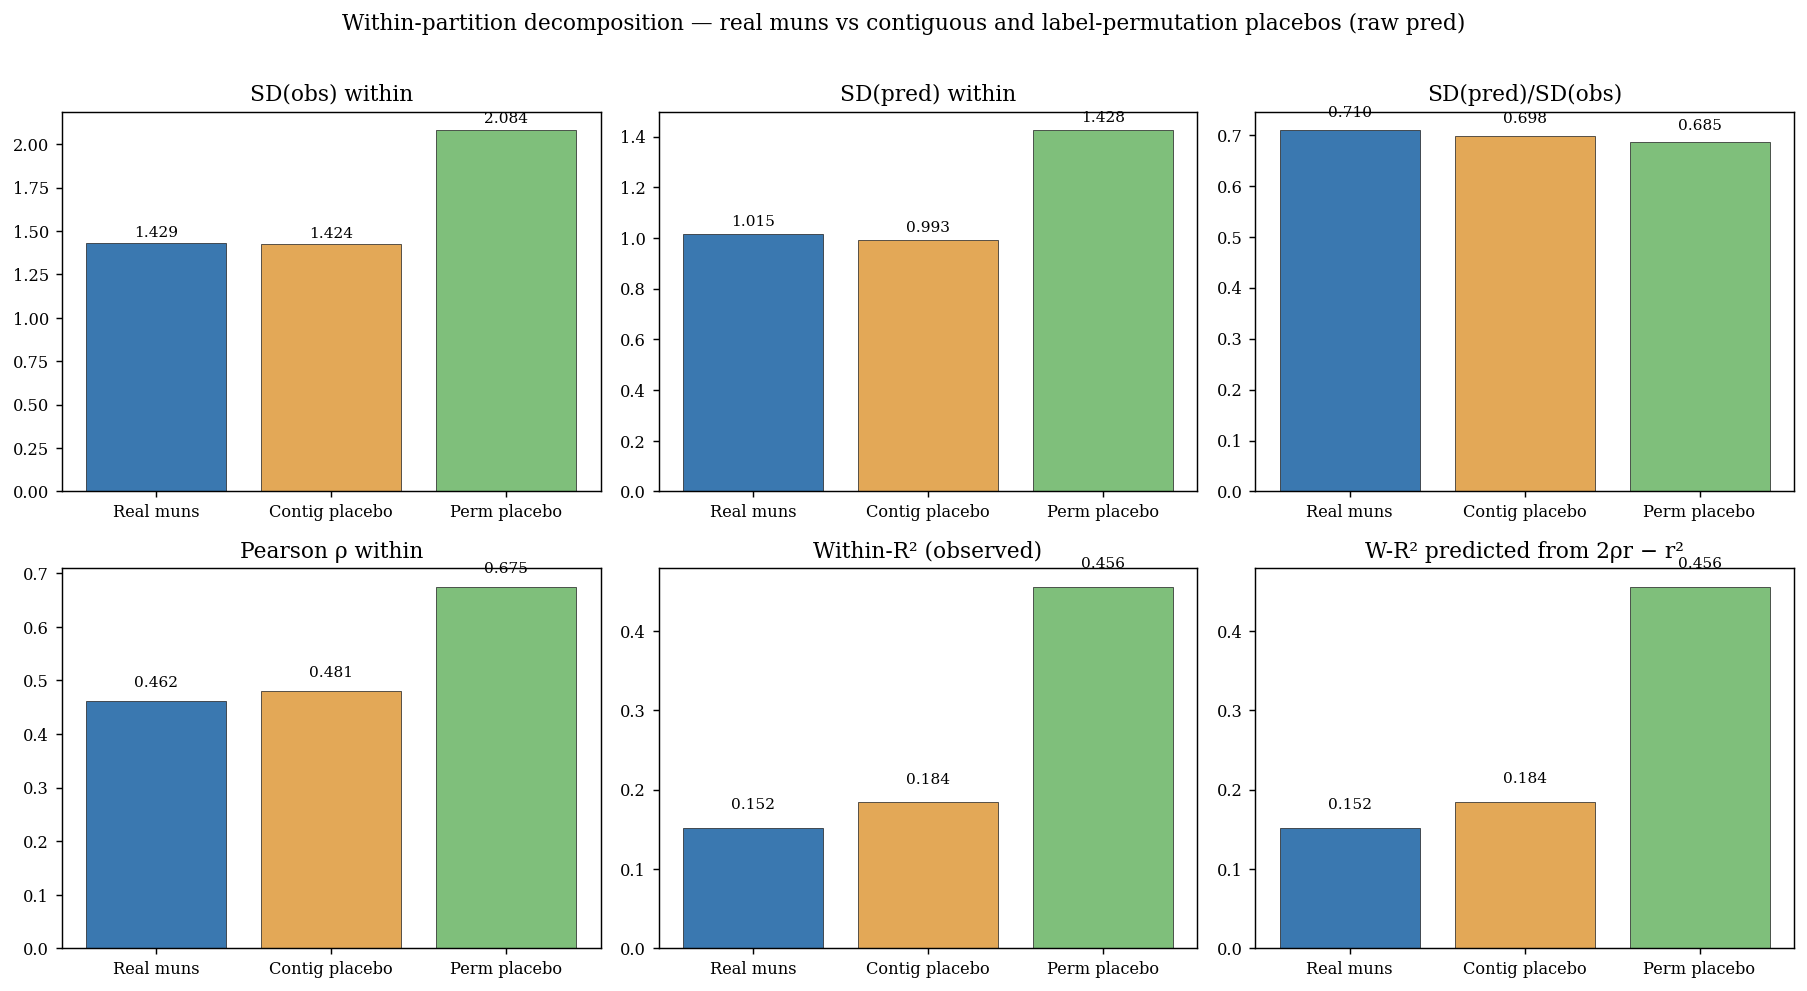

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_variance_compression_by_partition.png


In [13]:
# Visualize the decomposition: bars for SD(obs), SD(pred), ratio, rho, within_r2 by partition
labels = summary["partition"].tolist()
fields = [("sd_obs",  "SD(obs) within"),
          ("sd_pred", "SD(pred) within"),
          ("ratio",   "SD(pred)/SD(obs)"),
          ("rho",     "Pearson ρ within"),
          ("within_r2","Within-R² (observed)"),
          ("pred_wr2", "W-R² predicted from 2ρr − r²")]
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
colors = ["#3a78b0","#e3a857","#7fbf7b"]
for ax_i, (key, lab) in zip(axes.flatten(), fields):
    vals = summary[key].values
    bars = ax_i.bar(labels, vals, color=colors, edgecolor="#222", linewidth=0.4)
    ax_i.set_title(lab)
    ax_i.axhline(0, color="grey", lw=0.4)
    for b, v in zip(bars, vals):
        ax_i.text(b.get_x() + b.get_width()/2, v + (0.02 if v>=0 else -0.05),
                  f"{v:.3f}", ha="center", va="bottom" if v>=0 else "top", fontsize=8.5)
plt.suptitle("Within-partition decomposition — real muns vs contiguous and label-permutation placebos (raw pred)",
              y=1.01)
plt.tight_layout()
fig_varcomp = os.path.join(out_dir, "fig_variance_compression_by_partition.png")
fig.savefig(fig_varcomp, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_varcomp}")

#### Extension B — Repeat placebo experiment with corrected predictions (`pred_corr`)

The additive correction shifts each real mun's pred to match the SIAP municipal mean. For the **real** partition, this is a pure mun-level shift and within-R² is invariant to it (paper shows 0.152 → 0.154). For **placebo** partitions, the per-real-mun shifts become *within-placebo-mun variation* (since a placebo mun spans pieces of multiple real muns), so the corrected within-R² should differ from raw — by how much tells us how the correction interacts with the partition.

In [14]:
# Placebos with pred_corr (additive-corrected predictions)
df_corr = df_eval.dropna(subset=["yield","pred_corr"]).copy()
print(f"corrected eval frame: {len(df_corr):,} rows, {df_corr['muncode'].nunique()} muns")

real_wr2_corr = within_r2(df_corr, "yield", "pred_corr", "muncode")
print(f"Real W-R² (corrected) : {real_wr2_corr:+.4f}  (vs raw {real_wr2:+.4f})")

def run_placebo_eval(seed, eval_df, pred_col):
    rng = np.random.default_rng(seed)
    placebo_codes = pd.Series(index=eval_df.index, dtype=object)
    for st in eval_df["state"].unique():
        sub = eval_df[eval_df["state"] == st]
        clust = build_placebo_assignment(rng, st, sub, adj_per_state.get(st, {}))
        placebo_codes.loc[sub.index] = st + clust.astype(str).str.zfill(4)
    tmp = eval_df[["yield", pred_col]].copy()
    tmp["placebo_mun"] = placebo_codes
    return within_r2(tmp, "yield", pred_col, gc="placebo_mun")

import time
N_CORR = 100
contig_corr_vals = []
t0 = time.time()
for i in range(N_CORR):
    contig_corr_vals.append(run_placebo_eval(70000 + i, df_corr, "pred_corr"))
    if (i+1) % 25 == 0:
        print(f"  contig (corr) {i+1}/{N_CORR}  mean {np.mean(contig_corr_vals):+.4f}  elapsed {(time.time()-t0)/60:.1f} min")

perm_corr_vals = []
for i in range(N_CORR):
    rng = np.random.default_rng(80000 + i)
    permuted = df_corr[["yield","pred_corr","state","muncode"]].copy()
    new_codes = permuted["muncode"].to_numpy().copy()
    for st in permuted["state"].unique():
        mask = (permuted["state"] == st).to_numpy()
        idx = np.where(mask)[0]
        shuffled = rng.permutation(idx)
        new_codes[idx] = new_codes[shuffled]
    permuted["perm_mun"] = new_codes
    perm_corr_vals.append(within_r2(permuted, "yield", "pred_corr", "perm_mun"))

contig_corr_vals = np.asarray(contig_corr_vals)
perm_corr_vals   = np.asarray(perm_corr_vals)
print(f"\nCorrected predictions placebos:")
print(f"  Contig  mean {contig_corr_vals.mean():+.4f}  sd {contig_corr_vals.std():+.4f}")
print(f"  Perm    mean {perm_corr_vals.mean():+.4f}  sd {perm_corr_vals.std():+.4f}")

pd.concat([
    pd.DataFrame({"rep":range(N_CORR),"within_r2":contig_corr_vals,"kind":"contig_corr"}),
    pd.DataFrame({"rep":range(N_CORR),"within_r2":perm_corr_vals,  "kind":"perm_corr"}),
]).to_csv(os.path.join(out_dir,"placebo_within_r2_corrected.csv"), index=False)

corrected eval frame: 72,338 rows, 2027 muns
Real W-R² (corrected) : +0.1535  (vs raw +0.1521)


  contig (corr) 25/100  mean +0.0126  elapsed 0.2 min


  contig (corr) 50/100  mean +0.0125  elapsed 0.3 min


  contig (corr) 75/100  mean +0.0171  elapsed 0.5 min


  contig (corr) 100/100  mean +0.0172  elapsed 0.7 min



Corrected predictions placebos:
  Contig  mean +0.0172  sd +0.0423
  Perm    mean +0.3174  sd +0.0008


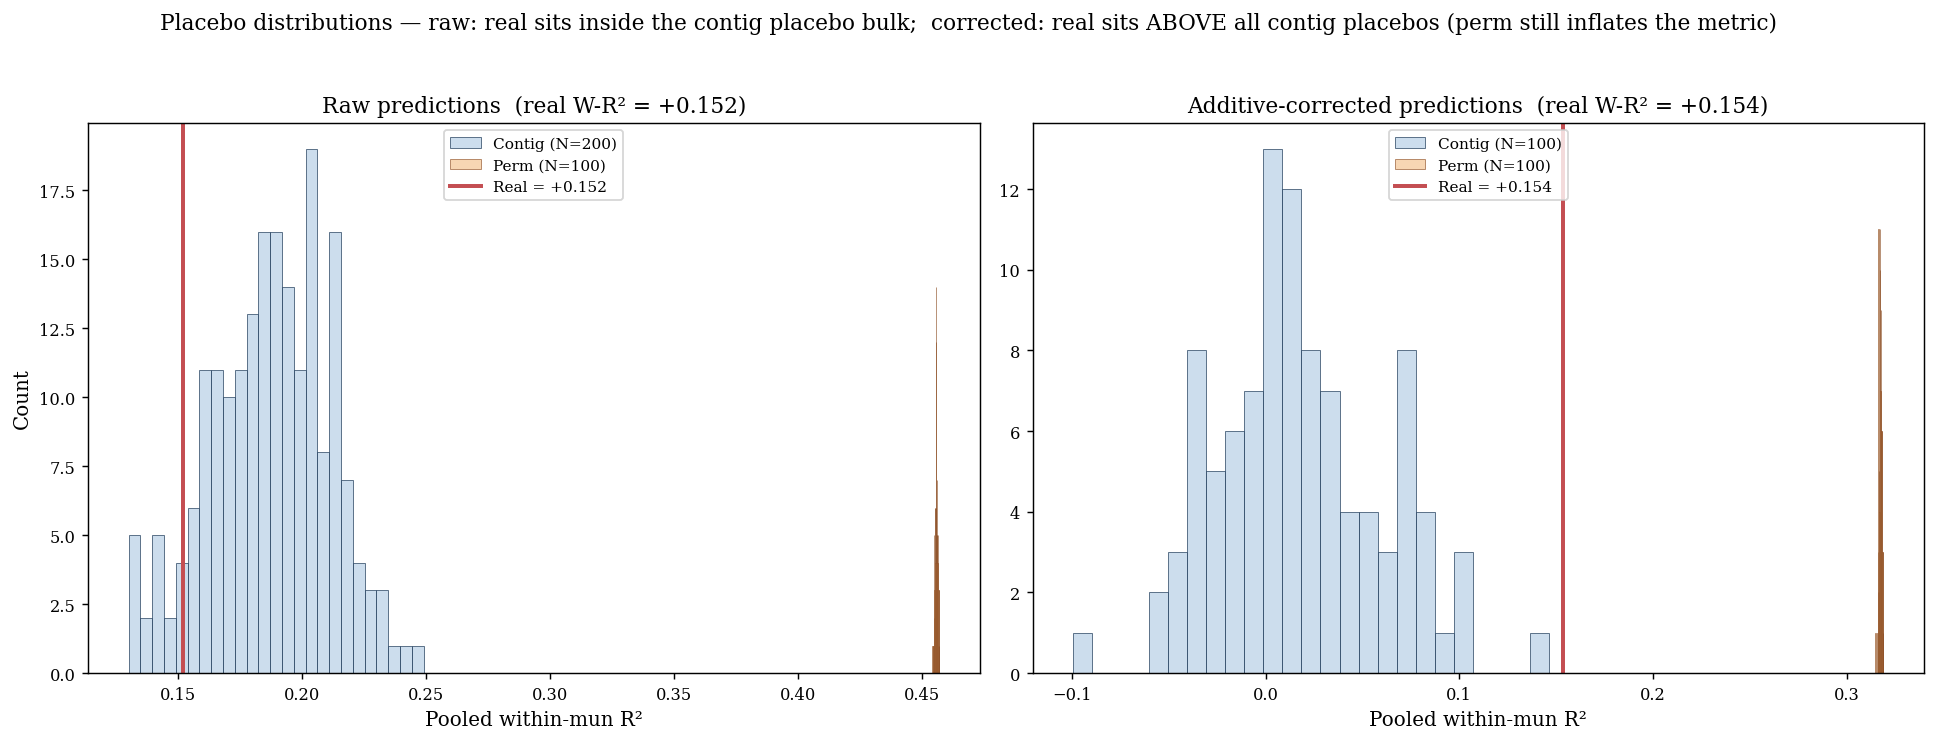

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_placebo_within_r2_hist_raw_vs_corr.png
version partition  within_r2     sd
    raw      Real     0.1521    NaN
    raw    Contig     0.1872 0.0241
    raw      Perm     0.4559 0.0005
   corr      Real     0.1535    NaN
   corr    Contig     0.0172 0.0423
   corr      Perm     0.3174 0.0008


In [15]:
# 2x1 histogram: raw vs corrected placebos, both kinds, with real W-R² on each
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)

ax = axes[0]
ax.hist(c_vals, bins=25, color="#bcd2e8", edgecolor="#1f3b5a", linewidth=0.5, alpha=0.75,
         label=f"Contig (N={len(c_vals)})")
ax.hist(p_vals, bins=25, color="#f4c08a", edgecolor="#8a4a1f", linewidth=0.5, alpha=0.65,
         label=f"Perm (N={len(p_vals)})")
ax.axvline(real_wr2, color="#c44e52", lw=2.2, label=f"Real = {real_wr2:+.3f}")
ax.set_title(f"Raw predictions  (real W-R² = {real_wr2:+.3f})")
ax.set_xlabel("Pooled within-mun R²"); ax.set_ylabel("Count")
ax.legend(loc="upper center", fontsize=8.5)

ax = axes[1]
ax.hist(contig_corr_vals, bins=25, color="#bcd2e8", edgecolor="#1f3b5a", linewidth=0.5, alpha=0.75,
         label=f"Contig (N={len(contig_corr_vals)})")
ax.hist(perm_corr_vals, bins=25, color="#f4c08a", edgecolor="#8a4a1f", linewidth=0.5, alpha=0.65,
         label=f"Perm (N={len(perm_corr_vals)})")
ax.axvline(real_wr2_corr, color="#c44e52", lw=2.2, label=f"Real = {real_wr2_corr:+.3f}")
ax.set_title(f"Additive-corrected predictions  (real W-R² = {real_wr2_corr:+.3f})")
ax.set_xlabel("Pooled within-mun R²")
ax.legend(loc="upper center", fontsize=8.5)

plt.suptitle("Placebo distributions — raw: real sits inside the contig placebo bulk;  "
              "corrected: real sits ABOVE all contig placebos (perm still inflates the metric)",
              y=1.03)
plt.tight_layout()
fig_corr_hist = os.path.join(out_dir, "fig_placebo_within_r2_hist_raw_vs_corr.png")
fig.savefig(fig_corr_hist, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_corr_hist}")

final = pd.DataFrame([
    {"version":"raw",  "partition":"Real",   "within_r2":real_wr2,                 "sd":np.nan},
    {"version":"raw",  "partition":"Contig", "within_r2":c_vals.mean(),             "sd":c_vals.std()},
    {"version":"raw",  "partition":"Perm",   "within_r2":p_vals.mean(),             "sd":p_vals.std()},
    {"version":"corr", "partition":"Real",   "within_r2":real_wr2_corr,             "sd":np.nan},
    {"version":"corr", "partition":"Contig", "within_r2":contig_corr_vals.mean(),   "sd":contig_corr_vals.std()},
    {"version":"corr", "partition":"Perm",   "within_r2":perm_corr_vals.mean(),     "sd":perm_corr_vals.std()},
])
print(final.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
final.to_csv(os.path.join(out_dir, "placebo_summary_raw_vs_corr.csv"), index=False)

#### Extension C — Per-state placebo test

The pooled placebo result is one number for all of Mexico. Break it out by state: for each state, compute the real within-R² (raw and corrected) and the mean of 20 contiguous-placebo within-R²s. The state-level comparison reveals where the model **actually** beats spatial-contiguity baseline (real > placebo) vs where the pooled metric is just inheriting the partition-variance inflator (real ≤ placebo).

In [16]:
# Per-state placebo test: real vs 20 contig placebos, by state, both raw and corrected predictions.
N_PER_STATE = 20

def state_within_r2(df, y, p, gc):
    """Per-state pooled within-R² (uses muns in that state only)."""
    out = {}
    for st, sub in df.groupby("state"):
        wr = within_r2(sub, y, p, gc)
        out[st] = wr
    return out

# Real (raw)
real_state_raw  = state_within_r2(df_eval, "yield", "pred", "muncode")
# Real (corrected)
real_state_corr = state_within_r2(df_corr, "yield", "pred_corr", "muncode")

def make_placebo_codes(rng, eval_df):
    codes = pd.Series(index=eval_df.index, dtype=object)
    for st in eval_df["state"].unique():
        sub = eval_df[eval_df["state"] == st]
        clust = build_placebo_assignment(rng, st, sub, adj_per_state.get(st, {}))
        codes.loc[sub.index] = st + clust.astype(str).str.zfill(4)
    return codes

import time
print("Per-state contig placebos (raw)...")
state_placebo_raw = {st: [] for st in df_eval["state"].unique()}
t0 = time.time()
for i in range(N_PER_STATE):
    rng = np.random.default_rng(90000 + i)
    codes = make_placebo_codes(rng, df_eval)
    tmp = df_eval[["yield","pred","state"]].copy()
    tmp["placebo_mun"] = codes
    res = state_within_r2(tmp, "yield", "pred", "placebo_mun")
    for st, v in res.items():
        state_placebo_raw[st].append(v)
    if (i+1) % 5 == 0:
        print(f"  raw rep {i+1}/{N_PER_STATE}  elapsed {(time.time()-t0)/60:.1f} min")

print("Per-state contig placebos (corr)...")
state_placebo_corr = {st: [] for st in df_corr["state"].unique()}
t0 = time.time()
for i in range(N_PER_STATE):
    rng = np.random.default_rng(91000 + i)
    codes = make_placebo_codes(rng, df_corr)
    tmp = df_corr[["yield","pred_corr","state"]].copy()
    tmp["placebo_mun"] = codes
    res = state_within_r2(tmp, "yield", "pred_corr", "placebo_mun")
    for st, v in res.items():
        state_placebo_corr[st].append(v)
    if (i+1) % 5 == 0:
        print(f"  corr rep {i+1}/{N_PER_STATE}  elapsed {(time.time()-t0)/60:.1f} min")

per_state = pd.DataFrame({
    "state": list(real_state_raw.keys()),
    "real_raw":  list(real_state_raw.values()),
    "placebo_raw_mean":  [np.mean(state_placebo_raw[st])  for st in real_state_raw],
    "placebo_raw_sd":    [np.std (state_placebo_raw[st])  for st in real_state_raw],
})
per_state["real_corr"] = per_state["state"].map(real_state_corr)
per_state["placebo_corr_mean"] = per_state["state"].map(lambda s: np.mean(state_placebo_corr.get(s,[np.nan])))
per_state["placebo_corr_sd"]   = per_state["state"].map(lambda s: np.std (state_placebo_corr.get(s,[np.nan])))
per_state = per_state.merge(state_names, on="state", how="left")
per_state.to_csv(os.path.join(out_dir, "per_state_placebo.csv"), index=False)

print("\nPer-state real-vs-placebo (raw + corrected), sorted by real_raw descending:")
print(per_state.sort_values("real_raw", ascending=False)
        [["state_name","real_raw","placebo_raw_mean","real_corr","placebo_corr_mean"]]
        .to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

Per-state contig placebos (raw)...


  raw rep 5/20  elapsed 0.1 min


  raw rep 10/20  elapsed 0.1 min


  raw rep 15/20  elapsed 0.2 min


  raw rep 20/20  elapsed 0.2 min
Per-state contig placebos (corr)...


  corr rep 5/20  elapsed 0.0 min


  corr rep 10/20  elapsed 0.1 min


  corr rep 15/20  elapsed 0.1 min


  corr rep 20/20  elapsed 0.2 min

Per-state real-vs-placebo (raw + corrected), sorted by real_raw descending:
           state_name   real_raw  placebo_raw_mean  real_corr  placebo_corr_mean
            Queretaro     +0.549            +0.577     +0.549             +0.332
               Sonora     +0.428            -0.224     +0.208             -0.564
              Sinaloa     +0.405            +0.452     +0.405             +0.217
           Guanajuato     +0.376            +0.393     +0.376             +0.348
              Hidalgo     +0.313            +0.365     +0.314             +0.196
              Durango     +0.226            +0.152     +0.233             -0.164
       Aguascalientes     +0.109            +0.152     +0.109             -0.466
            Michoacan     +0.105            +0.159     +0.110             +0.073
            Zacatecas     +0.103            +0.123     +0.110             -0.258
              Nayarit     +0.011            -0.026     +0.011             +0.00

Dropping degenerate states (n_muns<5 or n_rows<200):
         state_name  n_muns  n_rows
    Baja California       2      60
Baja California Sur       3      98

Using 29 states; clipping display at -1.0
           state_name  real_raw  placebo_raw_med  real_corr  placebo_corr_med
            Queretaro    +0.549           +0.609     +0.549            +0.364
               Sonora    +0.428           -0.100     +0.208            -0.239
              Sinaloa    +0.405           +0.450     +0.405            +0.221
           Guanajuato    +0.376           +0.395     +0.376            +0.346
              Hidalgo    +0.313           +0.371     +0.314            +0.195
              Durango    +0.226           +0.155     +0.233            -0.190
       Aguascalientes    +0.109           +0.192     +0.109            -0.463
            Michoacan    +0.105           +0.150     +0.110            +0.079
            Zacatecas    +0.103           +0.118     +0.110            -0.255
              Na

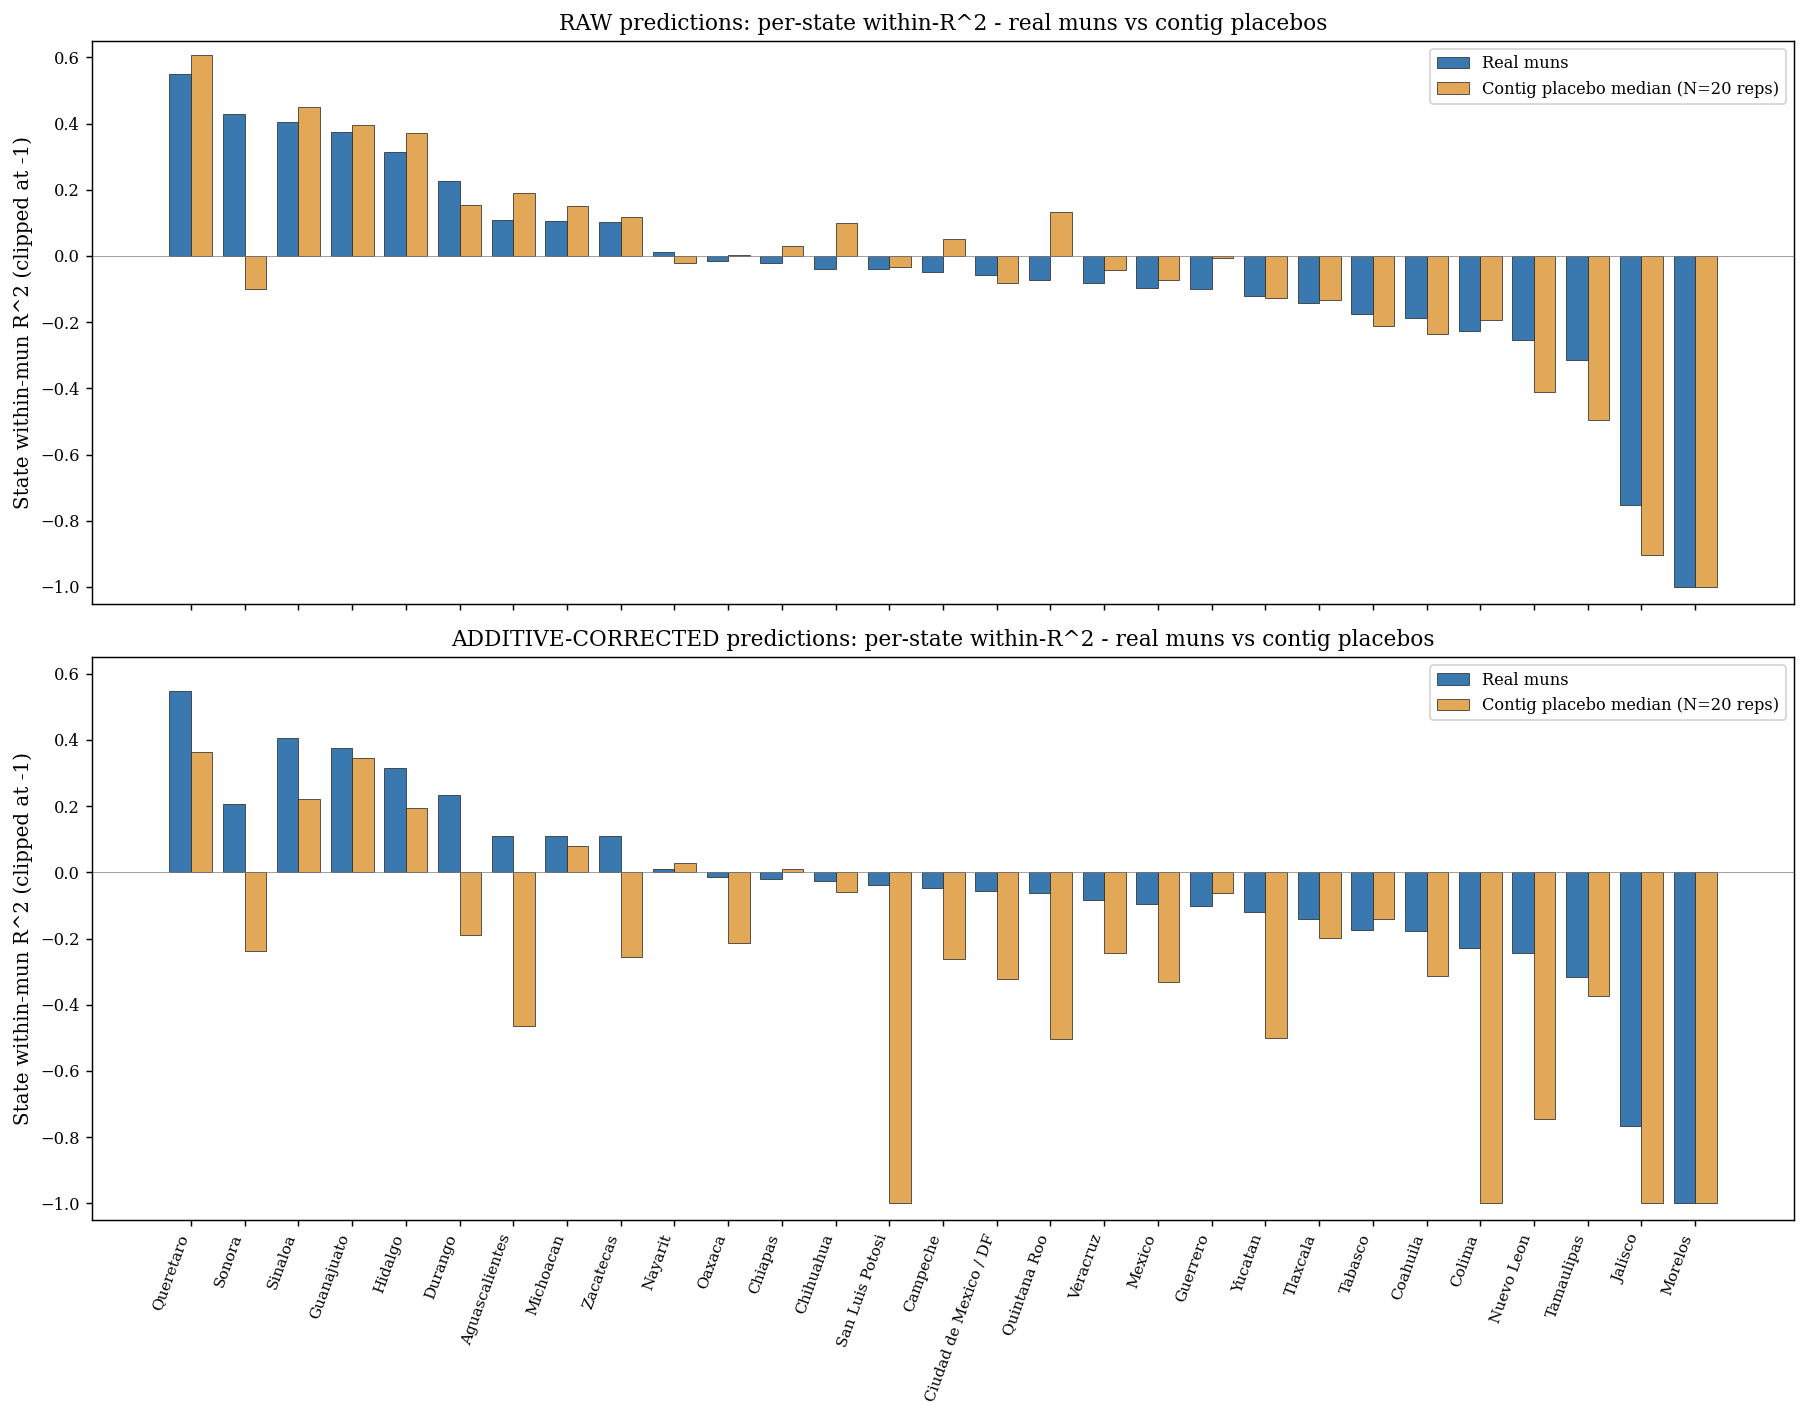

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_per_state_placebo.png


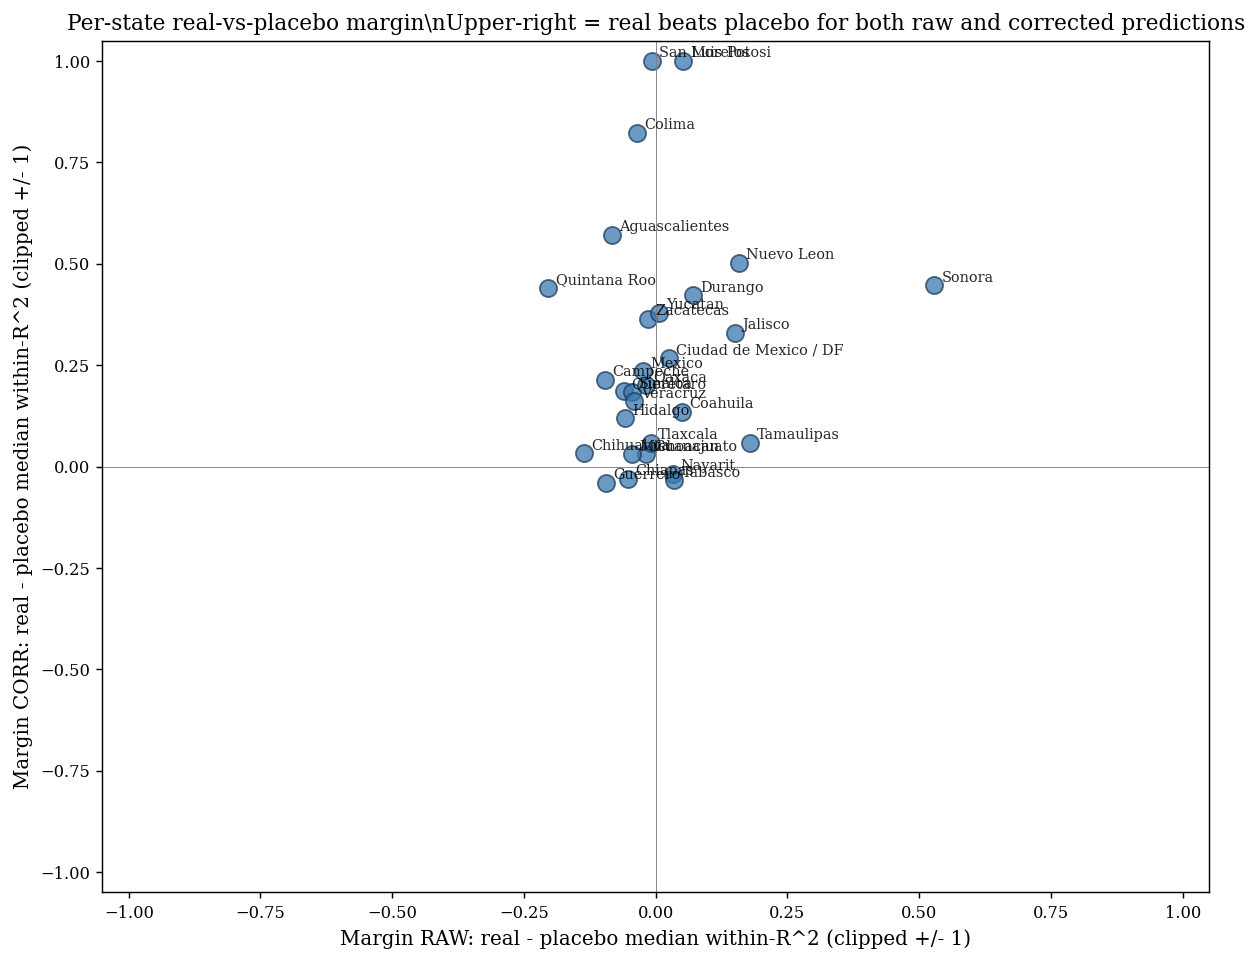

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_per_state_placebo_margin.png

Raw  predictions: real beats placebo median in 11/29 states
Corr predictions: real beats placebo median in 25/29 states


In [17]:
# Per-state plot with robust clipping (states with degenerate SS_tot in some placebos blow up).
# Use median across placebo reps + clip at -1 for visualization.

VIS_CLIP = -1.0  # tighter than -2 for plot scale
MIN_MUNS = 5
MIN_ROWS = 200

ps_full = per_state.copy()
ps_full["n_rows"] = ps_full["state"].map(df_eval.groupby("state").size().to_dict())
ps_full["n_muns"] = ps_full["state"].map(df_eval.groupby("state")["muncode"].nunique().to_dict())
keep = (ps_full["n_muns"] >= MIN_MUNS) & (ps_full["n_rows"] >= MIN_ROWS)
print(f"Dropping degenerate states (n_muns<{MIN_MUNS} or n_rows<{MIN_ROWS}):")
print(ps_full[~keep][["state_name","n_muns","n_rows"]].to_string(index=False))

# Use medians across reps (robust to degenerate placebos)
def med_or_nan(lst): return float(np.median(lst)) if len(lst) else np.nan
ps_full["placebo_raw_med"]  = ps_full["state"].map(lambda s: med_or_nan(state_placebo_raw.get(s,[])))
ps_full["placebo_corr_med"] = ps_full["state"].map(lambda s: med_or_nan(state_placebo_corr.get(s,[])))

ps = ps_full[keep].dropna(subset=["real_raw","placebo_raw_med"]).copy()
ps = ps.sort_values("real_raw", ascending=False).reset_index(drop=True)

print(f"\nUsing {len(ps)} states; clipping display at {VIS_CLIP}")
print(ps[["state_name","real_raw","placebo_raw_med","real_corr","placebo_corr_med"]]
        .to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

# Side-by-side bars
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
x = np.arange(len(ps))
w = 0.4

ax = axes[0]
ax.bar(x - w/2, ps["real_raw"].clip(lower=VIS_CLIP),  width=w,
        color="#3a78b0", edgecolor="#222", linewidth=0.4, label="Real muns")
ax.bar(x + w/2, ps["placebo_raw_med"].clip(lower=VIS_CLIP), width=w,
        color="#e3a857", edgecolor="#222", linewidth=0.4,
        label=f"Contig placebo median (N={N_PER_STATE} reps)")
ax.axhline(0, color="grey", lw=0.4)
ax.set_ylim(VIS_CLIP - 0.05, 0.65)
ax.set_ylabel("State within-mun R^2 (clipped at -1)")
ax.set_title(f"RAW predictions: per-state within-R^2 - real muns vs contig placebos")
ax.legend(loc="upper right")

ax = axes[1]
ax.bar(x - w/2, ps["real_corr"].clip(lower=VIS_CLIP),  width=w,
        color="#3a78b0", edgecolor="#222", linewidth=0.4, label="Real muns")
ax.bar(x + w/2, ps["placebo_corr_med"].clip(lower=VIS_CLIP), width=w,
        color="#e3a857", edgecolor="#222", linewidth=0.4,
        label=f"Contig placebo median (N={N_PER_STATE} reps)")
ax.axhline(0, color="grey", lw=0.4)
ax.set_ylim(VIS_CLIP - 0.05, 0.65)
ax.set_ylabel("State within-mun R^2 (clipped at -1)")
ax.set_title(f"ADDITIVE-CORRECTED predictions: per-state within-R^2 - real muns vs contig placebos")
ax.set_xticks(x)
ax.set_xticklabels(ps["state_name"], rotation=70, ha="right", fontsize=8.5)
ax.legend(loc="upper right")

plt.tight_layout()
fig_per_state = os.path.join(out_dir, "fig_per_state_placebo.png")
fig.savefig(fig_per_state, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_per_state}")

# Margin scatter: clip both axes to [-1, 1]
ps["margin_raw"]  = (ps["real_raw"]  - ps["placebo_raw_med"]).clip(-1, 1)
ps["margin_corr"] = (ps["real_corr"] - ps["placebo_corr_med"]).clip(-1, 1)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.scatter(ps["margin_raw"], ps["margin_corr"], s=90, color="#3a78b0", edgecolor="#1f3b5a", alpha=0.75)
for _, r in ps.iterrows():
    ax.annotate(r["state_name"], (r["margin_raw"], r["margin_corr"]),
                fontsize=8, alpha=0.85, xytext=(4,2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("Margin RAW: real - placebo median within-R^2 (clipped +/- 1)")
ax.set_ylabel("Margin CORR: real - placebo median within-R^2 (clipped +/- 1)")
ax.set_title("Per-state real-vs-placebo margin\\n"
              "Upper-right = real beats placebo for both raw and corrected predictions")
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
fig_margin = os.path.join(out_dir, "fig_per_state_placebo_margin.png")
fig.savefig(fig_margin, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_margin}")

# Final tally
n_real_wins_raw = (ps["margin_raw"]  > 0).sum()
n_real_wins_cor = (ps["margin_corr"] > 0).sum()
print(f"\nRaw  predictions: real beats placebo median in {n_real_wins_raw}/{len(ps)} states")
print(f"Corr predictions: real beats placebo median in {n_real_wins_cor}/{len(ps)} states")
ps_full.to_csv(os.path.join(out_dir,"per_state_placebo.csv"), index=False)


#### Extension D - Geographic visualization of one placebo realization for Sonora

Sonora is the standout state (real within-R^2 = +0.43, placebo median = -0.63 -- the model genuinely outperforms partition-based baselines here). Show the real mun boundaries colored by within-R^2 next to one placebo realization colored by the same metric to make the placebo construction visually concrete.

Sonora total ADCs in shapefile: 13,157
Sonora real muns total: 72


  mean degree (full Sonora): 5.66
  real mun size distribution: top 5 sizes [1036, 1036, 747, 734, 450], min 9, total ADCs 13157
  built 143 placebo clusters (real muns: 72)
  eval ADCs unmapped (not in shapefile): 0
  Sonora pooled W-R^2: real +0.428, placebo +0.196


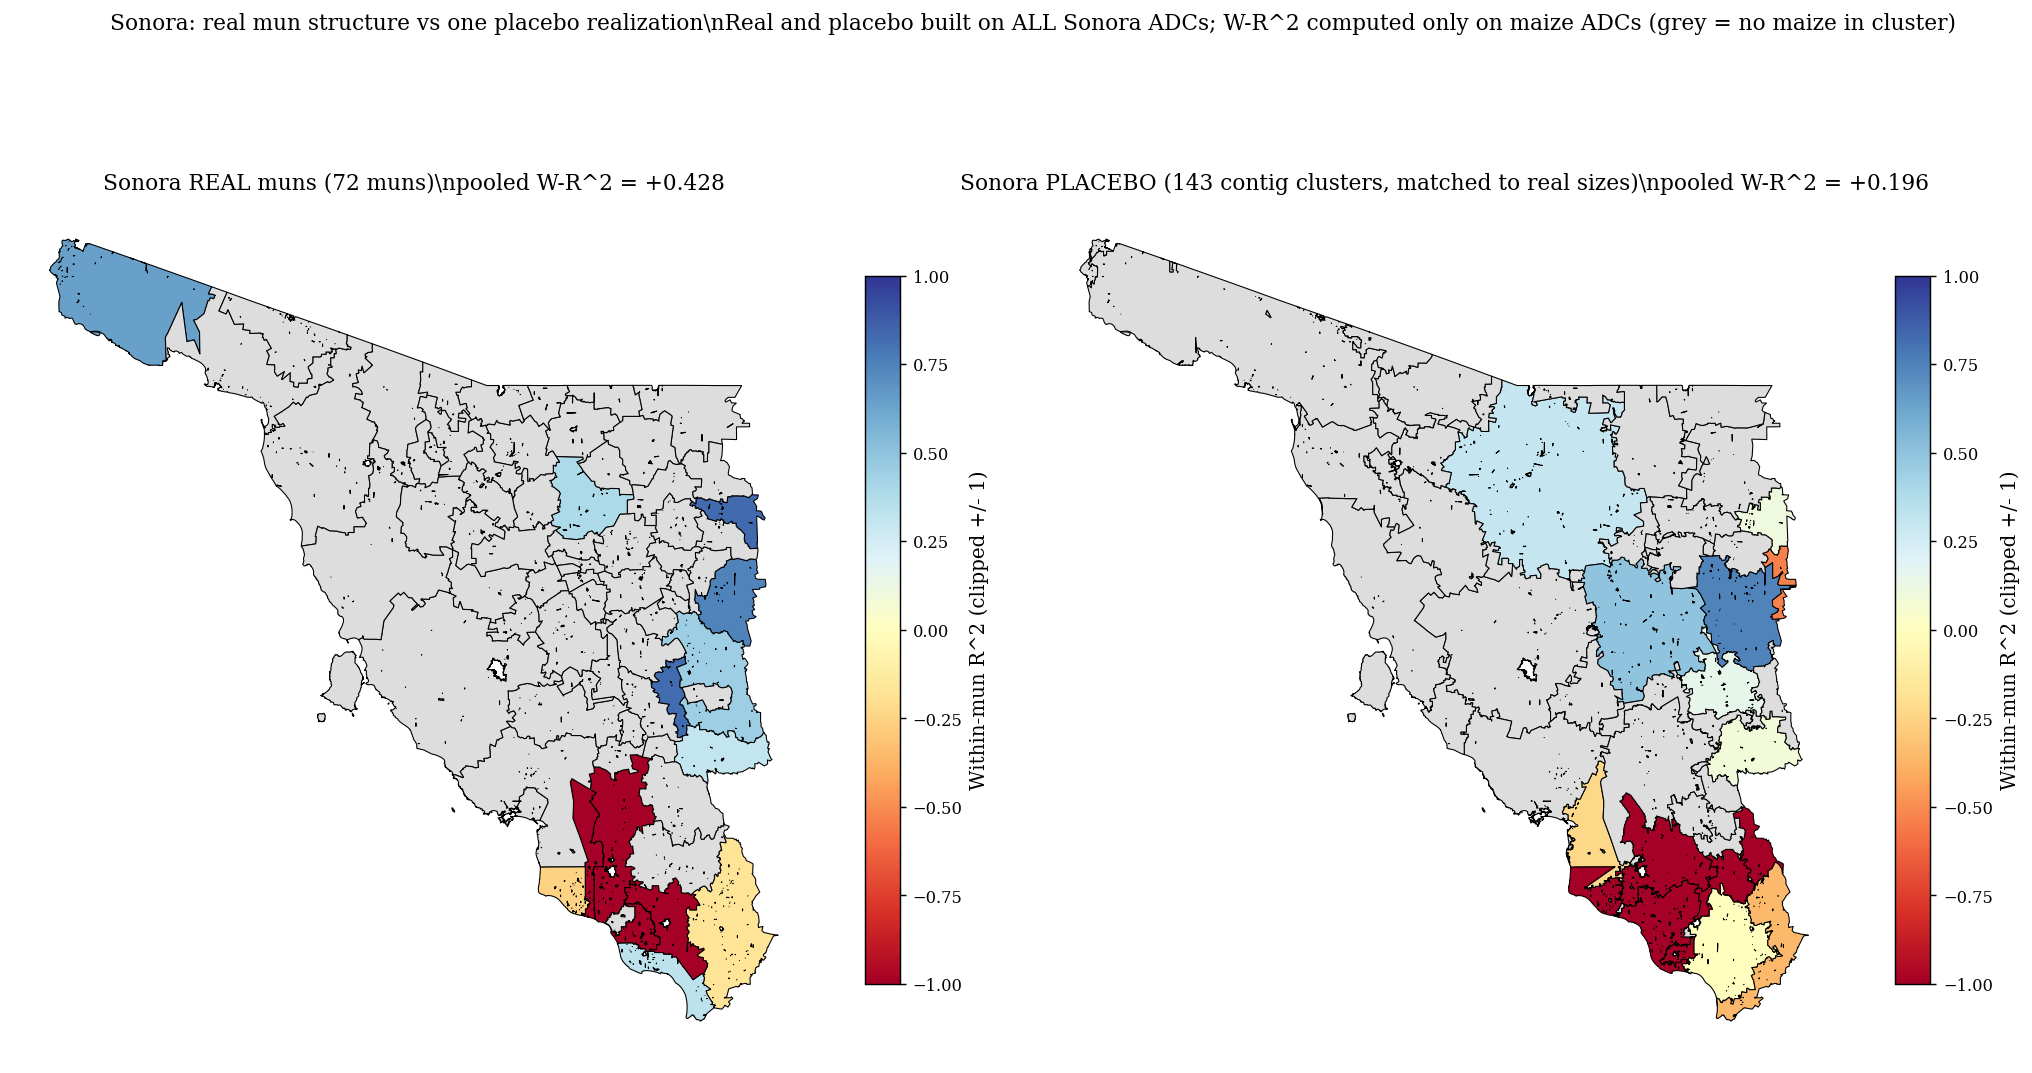

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_sonora_real_vs_placebo_map.png


In [18]:
# Sonora map -- fixed version: build placebo on ALL Sonora ADCs (not just eval-filtered)
# so contiguous clusters can form properly. Then attribute each eval ADC to whichever
# placebo cluster contains it. This matches how real muns work (they contain both maize
# and non-maize ADCs, but only maize ADCs appear in eval).

from collections import defaultdict, deque

state_code = "26"

# Load ALL Sonora ADCs from shapefile (~9,736)
gdf_all = gpd.read_file(adc_shp)
gdf_all = gdf_all.rename(columns={"adcid":"adc"})
gdf_all["adc"] = gdf_all["adc"].astype(str).str.replace("-","",regex=False)
gdf_all = gdf_all[gdf_all["adc"].str.startswith(state_code)].copy()
gdf_all = gdf_all.dissolve(by="adc", as_index=False)
gdf_all["muncode"] = gdf_all["adc"].str[:5]
print(f"Sonora total ADCs in shapefile: {len(gdf_all):,}")
print(f"Sonora real muns total: {gdf_all['muncode'].nunique()}")

# Build adjacency on all Sonora ADCs
sjoin = gpd.sjoin(gdf_all[["adc","geometry"]], gdf_all[["adc","geometry"]], how="inner", predicate="touches")
adj_full = defaultdict(set)
for a, b in zip(sjoin["adc_left"], sjoin["adc_right"]):
    if a != b:
        adj_full[a].add(b)
for a in gdf_all["adc"]:
    adj_full.setdefault(a, set())
adj_full = {k: list(v) for k, v in adj_full.items()}
print(f"  mean degree (full Sonora): {np.mean([len(v) for v in adj_full.values()]):.2f}")

# Real mun size distribution (ADC counts per real mun, ALL ADCs)
real_sizes = gdf_all.groupby("muncode").size().sort_values(ascending=False).tolist()
print(f"  real mun size distribution: top 5 sizes {real_sizes[:5]}, min {min(real_sizes)}, total ADCs {sum(real_sizes)}")

# Build ONE placebo partition: BFS to grow contiguous clusters matching real sizes
rng = np.random.default_rng(2026527)
all_adcs = gdf_all["adc"].tolist()
unassigned = set(all_adcs)
cluster_of = {}
cid = 0
for tgt in real_sizes:
    if not unassigned: break
    seed = rng.choice(list(unassigned))
    q = deque([seed])
    taken = []
    rows = 0
    while q and rows < tgt:
        v = q.popleft()
        if v not in unassigned or v in taken: continue
        taken.append(v)
        rows += 1
        nbrs = [n for n in adj_full.get(v, []) if n in unassigned and n not in taken]
        rng.shuffle(nbrs)
        q.extend(nbrs)
    for a in taken:
        cluster_of[a] = cid
        unassigned.discard(a)
    cid += 1
# Any leftovers: attach to nearest assigned neighbor (preserve contiguity, no singletons)
leftover_passes = 0
while unassigned and leftover_passes < 100:
    leftover_passes += 1
    progress = False
    for a in list(unassigned):
        for n in adj_full.get(a, []):
            if n in cluster_of:
                cluster_of[a] = cluster_of[n]
                unassigned.discard(a)
                progress = True
                break
    if not progress: break
# Any still-unassigned ADCs (truly isolated): own cluster
for a in list(unassigned):
    cluster_of[a] = cid
    cid += 1
print(f"  built {cid} placebo clusters (real muns: {len(real_sizes)})")

# Map placebo cluster onto every Sonora ADC in eval frame
sonora_eval = df_eval[df_eval["state"] == state_code].dropna(subset=["yield","pred"]).copy()
sonora_eval["placebo_mun"] = sonora_eval["adc"].astype(str).map(cluster_of)
n_unmapped = sonora_eval["placebo_mun"].isna().sum()
print(f"  eval ADCs unmapped (not in shapefile): {n_unmapped}")
sonora_eval = sonora_eval.dropna(subset=["placebo_mun"])
sonora_eval["placebo_mun"] = state_code + sonora_eval["placebo_mun"].astype(int).astype(str).str.zfill(4)

real_pooled    = within_r2(sonora_eval, "yield", "pred", "muncode")
placebo_pooled = within_r2(sonora_eval, "yield", "pred", "placebo_mun")
print(f"  Sonora pooled W-R^2: real {real_pooled:+.3f}, placebo {placebo_pooled:+.3f}")

# Per-group within-R^2
def per_group_wr2(df, y, p, gc):
    s = df[[y,p,gc]].dropna()
    cnt = s.groupby(gc).size()
    s = s[s[gc].isin(cnt[cnt>=2].index)]
    gm = s.groupby(gc)[[y,p]].transform("mean")
    dy, dp = s[y]-gm[y], s[p]-gm[p]
    out = []
    for g, idx in s.groupby(gc).groups.items():
        ddy = dy.loc[idx]; ddp = dp.loc[idx]
        sst = (ddy**2).sum()
        wr = 1 - ((ddy-ddp)**2).sum()/sst if sst>0 else np.nan
        out.append({"group":g, "within_r2":wr})
    return pd.DataFrame(out)

real_wr2_son = per_group_wr2(sonora_eval, "yield","pred","muncode").rename(columns={"group":"muncode"})
plac_wr2_son = per_group_wr2(sonora_eval, "yield","pred","placebo_mun").rename(columns={"group":"placebo_mun"})
real_wr2_son["within_r2_clipped"] = real_wr2_son["within_r2"].clip(-1, 1)
plac_wr2_son["within_r2_clipped"] = plac_wr2_son["within_r2"].clip(-1, 1)

# Attach within-R^2 to geometries via dissolve
real_polys = gdf_all.dissolve(by="muncode", as_index=False).merge(real_wr2_son, on="muncode", how="left")
gdf_all2 = gdf_all.copy()
gdf_all2["placebo_mun"] = gdf_all2["adc"].map(cluster_of).apply(lambda c: state_code + str(int(c)).zfill(4) if pd.notna(c) else None)
plac_polys = gdf_all2.dissolve(by="placebo_mun", as_index=False).merge(plac_wr2_son, on="placebo_mun", how="left")

# Plot
from matplotlib.colors import TwoSlopeNorm
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
cmap = plt.cm.RdYlBu

real_polys.plot(ax=axes[0], column="within_r2_clipped", cmap=cmap, norm=norm,
                  edgecolor="black", linewidth=0.6, missing_kwds={"color":"#dddddd","label":"No maize"},
                  legend=True, legend_kwds={"label":"Within-mun R^2 (clipped +/- 1)","shrink":0.65})
axes[0].set_title(f"Sonora REAL muns ({real_polys['muncode'].nunique()} muns)\\n"
                  f"pooled W-R^2 = {real_pooled:+.3f}")
axes[0].set_axis_off()

plac_polys.plot(ax=axes[1], column="within_r2_clipped", cmap=cmap, norm=norm,
                  edgecolor="black", linewidth=0.6, missing_kwds={"color":"#dddddd","label":"No maize"},
                  legend=True, legend_kwds={"label":"Within-mun R^2 (clipped +/- 1)","shrink":0.65})
axes[1].set_title(f"Sonora PLACEBO ({plac_polys['placebo_mun'].nunique()} contig clusters, matched to real sizes)\\n"
                  f"pooled W-R^2 = {placebo_pooled:+.3f}")
axes[1].set_axis_off()

plt.suptitle("Sonora: real mun structure vs one placebo realization\\n"
              "Real and placebo built on ALL Sonora ADCs; W-R^2 computed only on maize ADCs (grey = no maize in cluster)",
              y=1.01)
plt.tight_layout()
fig_son = os.path.join(out_dir, "fig_sonora_real_vs_placebo_map.png")
fig.savefig(fig_son, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_son}")


#### Extension E - Redo placebos with FULL ADC adjacency (methodological correction)

Earlier Extensions C and D used adjacency built from only the maize-relevant ADCs in the eval frame. That over-fragmented placebos in maize-sparse states (e.g. Sonora's irrigated valleys, separated by desert). The correct construction: build placebo clusters from ALL ADCs in each state (matching real mun sizes), then compute within-R^2 only on eval ADCs in each cluster. This mirrors how real muns work: they span maize and non-maize land, and the within-R^2 calc only uses ADCs with maize observations.

In [19]:
# Redo pooled + per-state placebos with full adjacency
import pickle
from collections import deque
import time

with open(os.path.join(out_dir, "placebo_adc_adjacency_full.pkl"), "rb") as f:
    full = pickle.load(f)
adj_full       = full["adj"]
adcs_per_state = full["adcs"]
mun_sizes_full = full["mun_sizes"]

# Filter to states present in df_eval
states_in_eval = set(df_eval["state"].unique())
print("Full adj covers", len(adj_full), "states; eval covers", len(states_in_eval))

def build_placebo_full(rng, st):
    """Partition ALL state ADCs into contiguous clusters matching real mun size distribution."""
    sizes = sorted(mun_sizes_full[st], reverse=True)
    adcs  = adcs_per_state[st]
    adj   = adj_full[st]
    unassigned = set(adcs)
    cluster_of = {}
    cid = 0
    for tgt in sizes:
        if not unassigned: break
        seed = rng.choice(list(unassigned))
        q = deque([seed])
        taken = []
        rows = 0
        while q and rows < tgt:
            v = q.popleft()
            if v not in unassigned or v in taken: continue
            taken.append(v)
            rows += 1
            nbrs = [n for n in adj.get(v, []) if n in unassigned and n not in taken]
            rng.shuffle(nbrs)
            q.extend(nbrs)
        for a in taken:
            cluster_of[a] = cid
            unassigned.discard(a)
        cid += 1
    # Attach leftover ADCs to nearest assigned neighbor (multiple passes)
    for _ in range(50):
        if not unassigned: break
        progress = False
        for a in list(unassigned):
            for n in adj.get(a, []):
                if n in cluster_of:
                    cluster_of[a] = cluster_of[n]
                    unassigned.discard(a)
                    progress = True
                    break
        if not progress: break
    # Truly isolated -> own cluster
    for a in list(unassigned):
        cluster_of[a] = cid
        cid += 1
    return cluster_of

def run_placebo_full(seed, eval_df, pred_col):
    rng = np.random.default_rng(seed)
    cluster_codes = pd.Series(index=eval_df.index, dtype=object)
    for st in eval_df["state"].unique():
        if st not in adj_full:
            continue
        cof = build_placebo_full(rng, st)
        sub_idx = eval_df.index[eval_df["state"] == st]
        cluster_codes.loc[sub_idx] = (eval_df.loc[sub_idx, "adc"].astype(str)
                                       .map(cof).apply(lambda c: st + str(int(c)).zfill(4) if pd.notna(c) else None))
    tmp = eval_df[["yield", pred_col]].copy()
    tmp["placebo_mun"] = cluster_codes
    return within_r2(tmp.dropna(subset=["placebo_mun"]), "yield", pred_col, gc="placebo_mun")

# Pooled placebo: 200 reps with full adjacency, raw predictions
N_POOLED = 200
contig_full_vals = []
t0 = time.time()
for i in range(N_POOLED):
    contig_full_vals.append(run_placebo_full(110000 + i, df_eval, "pred"))
    if (i+1) % 25 == 0:
        print(f"  pooled raw {i+1}/{N_POOLED}  mean {np.mean(contig_full_vals):+.4f}  elapsed {(time.time()-t0)/60:.1f} min")
contig_full_vals = np.asarray(contig_full_vals)

contig_full_corr_vals = []
t0 = time.time()
for i in range(N_POOLED):
    contig_full_corr_vals.append(run_placebo_full(120000 + i, df_corr, "pred_corr"))
    if (i+1) % 25 == 0:
        print(f"  pooled corr {i+1}/{N_POOLED}  mean {np.mean(contig_full_corr_vals):+.4f}  elapsed {(time.time()-t0)/60:.1f} min")
contig_full_corr_vals = np.asarray(contig_full_corr_vals)

print(f"\nFull-adjacency POOLED placebos:")
print(f"  raw : mean {contig_full_vals.mean():+.4f}  sd {contig_full_vals.std():+.4f}  vs real {real_wr2:+.4f}")
print(f"  corr: mean {contig_full_corr_vals.mean():+.4f}  sd {contig_full_corr_vals.std():+.4f}  vs real {real_wr2_corr:+.4f}")

# Per-state placebos (raw + corr), 20 reps each
N_PER_STATE_F = 20
state_placebo_full_raw  = {st: [] for st in df_eval["state"].unique() if st in adj_full}
state_placebo_full_corr = {st: [] for st in df_corr["state"].unique() if st in adj_full}

t0 = time.time()
for i in range(N_PER_STATE_F):
    rng = np.random.default_rng(130000 + i)
    cluster_codes_raw  = pd.Series(index=df_eval.index, dtype=object)
    cluster_codes_corr = pd.Series(index=df_corr.index, dtype=object)
    for st in adj_full:
        if st not in states_in_eval: continue
        cof = build_placebo_full(rng, st)
        # raw
        sub_idx = df_eval.index[df_eval["state"] == st]
        cluster_codes_raw.loc[sub_idx] = (df_eval.loc[sub_idx, "adc"].astype(str)
                                           .map(cof).apply(lambda c: st + str(int(c)).zfill(4) if pd.notna(c) else None))
        # corr
        sub_idx2 = df_corr.index[df_corr["state"] == st]
        cluster_codes_corr.loc[sub_idx2] = (df_corr.loc[sub_idx2, "adc"].astype(str)
                                             .map(cof).apply(lambda c: st + str(int(c)).zfill(4) if pd.notna(c) else None))
    tmp_raw  = df_eval[["yield","pred","state"]].copy(); tmp_raw["placebo_mun"]  = cluster_codes_raw
    tmp_corr = df_corr[["yield","pred_corr","state"]].copy(); tmp_corr["placebo_mun"] = cluster_codes_corr
    for st in state_placebo_full_raw:
        sub = tmp_raw[tmp_raw["state"]==st].dropna(subset=["placebo_mun"])
        state_placebo_full_raw[st].append(within_r2(sub, "yield", "pred", "placebo_mun"))
    for st in state_placebo_full_corr:
        sub = tmp_corr[tmp_corr["state"]==st].dropna(subset=["placebo_mun"])
        state_placebo_full_corr[st].append(within_r2(sub, "yield", "pred_corr", "placebo_mun"))
    if (i+1) % 5 == 0:
        print(f"  per-state full rep {i+1}/{N_PER_STATE_F}  elapsed {(time.time()-t0)/60:.1f} min")

per_state_full = pd.DataFrame({
    "state": list(real_state_raw.keys()),
    "real_raw":  list(real_state_raw.values()),
    "real_corr": [real_state_corr.get(s,np.nan) for s in real_state_raw],
    "placebo_full_raw_med":  [float(np.median(state_placebo_full_raw.get(s,[np.nan])))  for s in real_state_raw],
    "placebo_full_corr_med": [float(np.median(state_placebo_full_corr.get(s,[np.nan]))) for s in real_state_raw],
}).merge(state_names, on="state", how="left")
per_state_full.to_csv(os.path.join(out_dir, "per_state_placebo_full_adj.csv"), index=False)

print("\nPer-state (FULL adjacency), sorted by real_raw desc:")
print(per_state_full.sort_values("real_raw", ascending=False)
        [["state_name","real_raw","placebo_full_raw_med","real_corr","placebo_full_corr_med"]]
        .to_string(index=False, float_format=lambda x: f"{x:+.3f}"))


Full adj covers 32 states; eval covers 31


  pooled raw 25/200  mean +0.2001  elapsed 1.3 min


  pooled raw 50/200  mean +0.2016  elapsed 2.7 min


  pooled raw 75/200  mean +0.2006  elapsed 4.0 min


  pooled raw 100/200  mean +0.1999  elapsed 5.4 min


...

  pooled corr 200/200  mean +0.0446  elapsed 10.7 min

Full-adjacency POOLED placebos:
  raw : mean +0.1998  sd +0.0143  vs real +0.1521
  corr: mean +0.0446  sd +0.0252  vs real +0.1535


  per-state full rep 5/20  elapsed 0.3 min


  per-state full rep 10/20  elapsed 0.6 min


  per-state full rep 15/20  elapsed 0.9 min


  per-state full rep 20/20  elapsed 1.2 min

Per-state (FULL adjacency), sorted by real_raw desc:
           state_name   real_raw  placebo_full_raw_med  real_corr  placebo_full_corr_med
            Queretaro     +0.549                +0.557     +0.549                 +0.358
               Sonora     +0.428                +0.492     +0.208                 +0.194
              Sinaloa     +0.405                +0.446     +0.405                 +0.485
           Guanajuato     +0.376                +0.378     +0.376                 +0.312
              Hidalgo     +0.313                +0.363     +0.314                 +0.182
              Durango     +0.226                +0.252     +0.233                 -0.189
       Aguascalientes     +0.109                +0.141     +0.109                 -0.479
            Michoacan     +0.105                +0.192     +0.110                 +0.029
            Zacatecas     +0.103                +0.108     +0.110                 -0.214
            

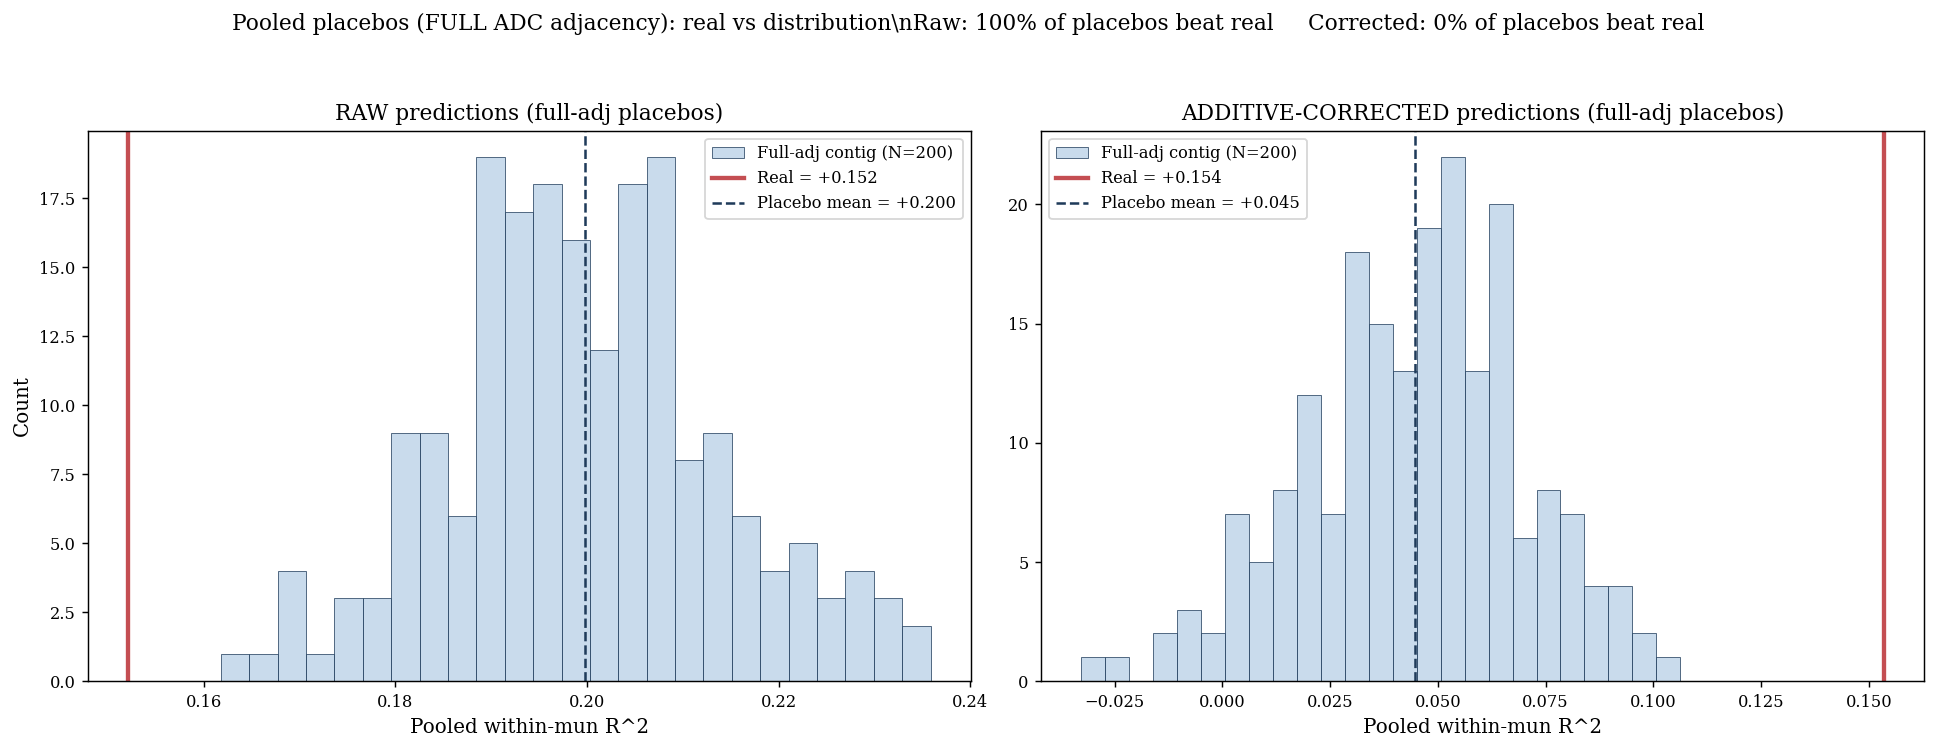

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_placebo_hist_full_adj.png


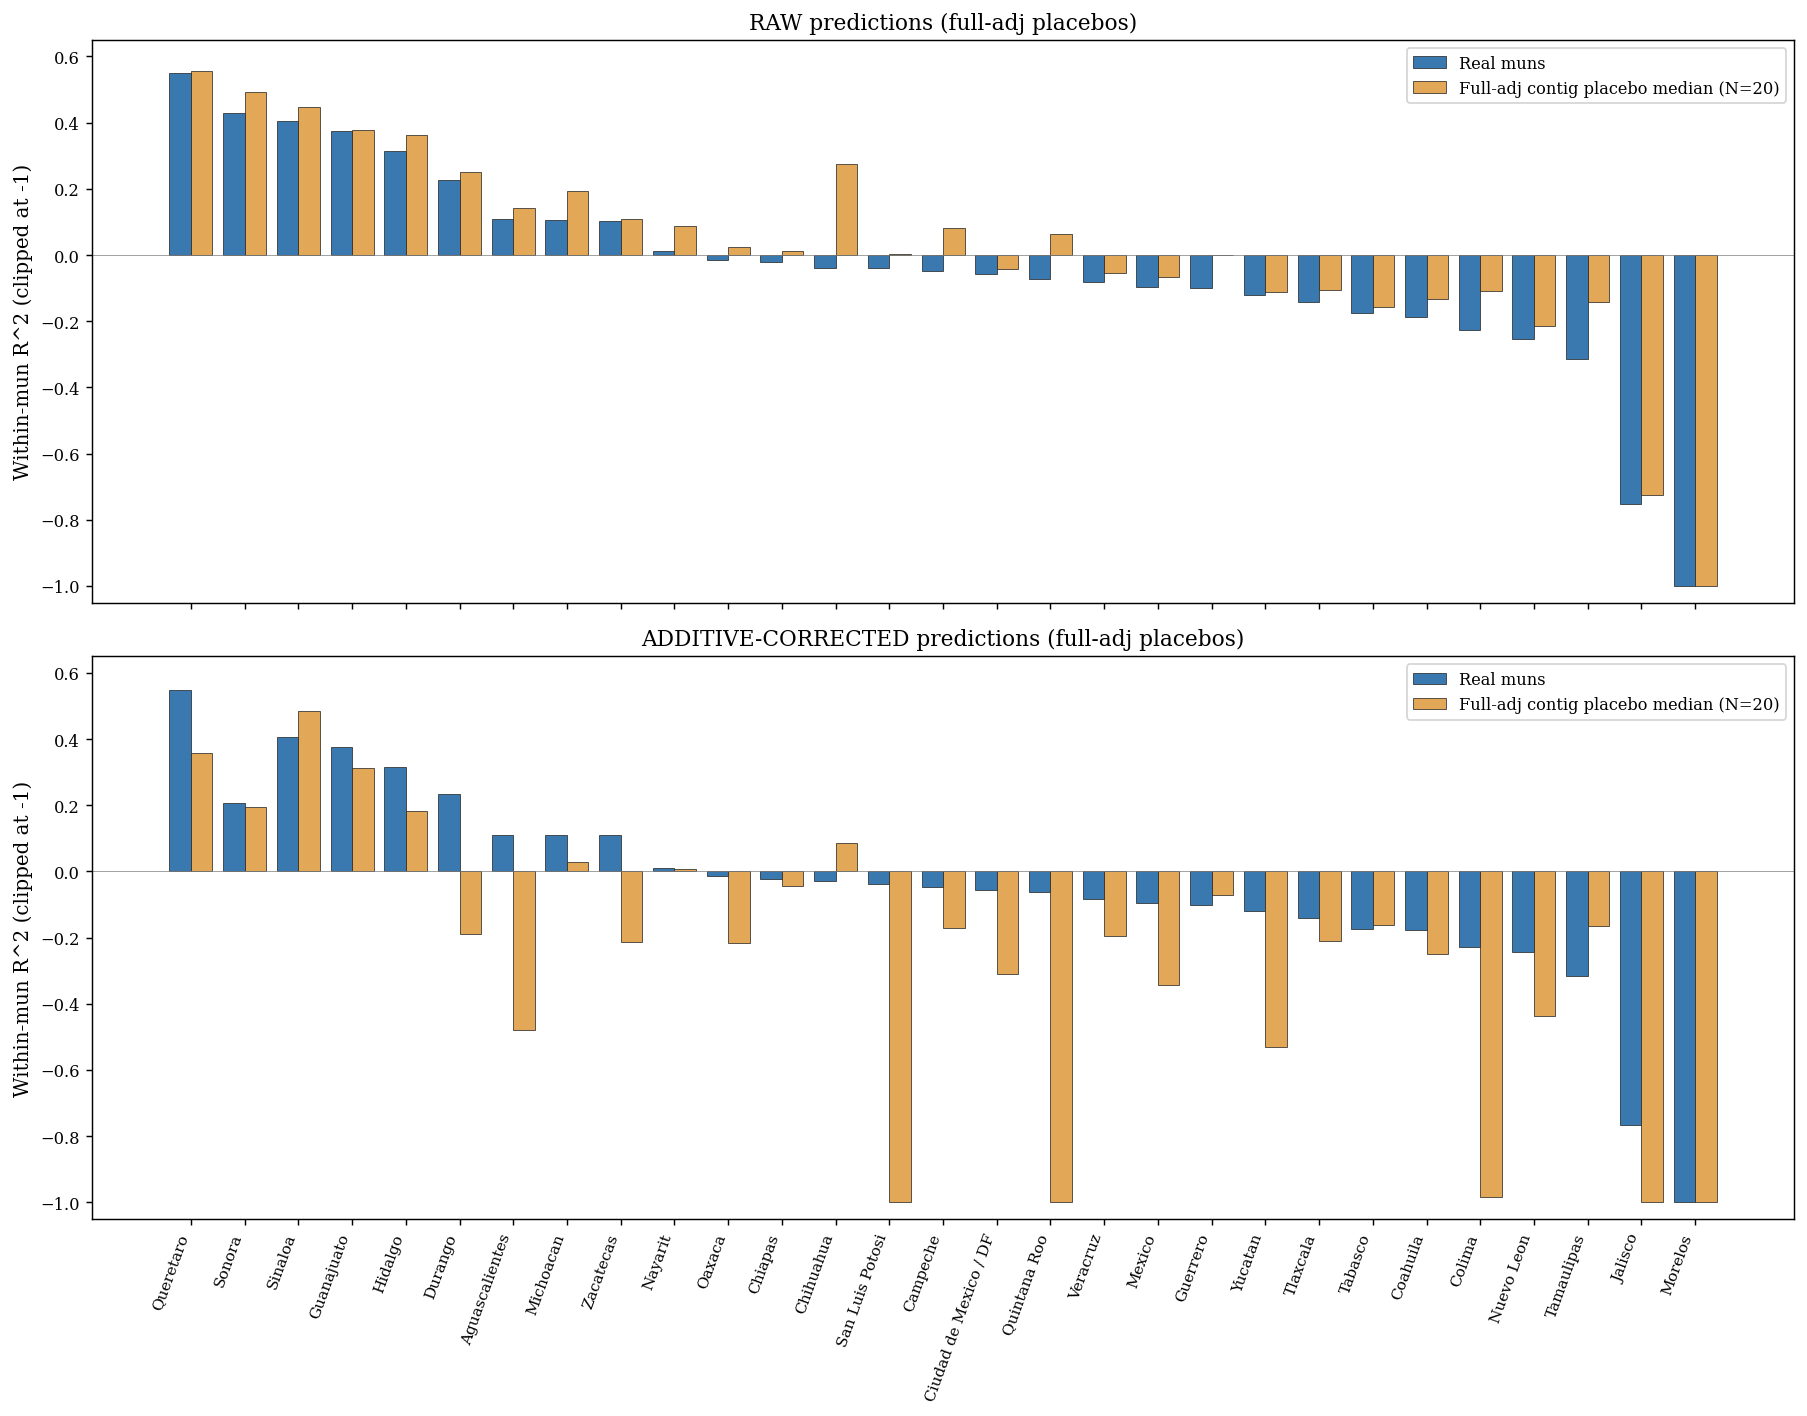

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_per_state_placebo_full_adj.png

Full-adj results: real beats placebo median (raw): 0/29
Full-adj results: real beats placebo median (corr): 24/29

Eval-only vs full-adj placebo (corrected):
           state_name  real_corr  placebo_eval_corr  placebo_full_corr_med
            Queretaro     +0.549             +0.332                 +0.358
              Sinaloa     +0.405             +0.217                 +0.485
           Guanajuato     +0.376             +0.348                 +0.312
              Hidalgo     +0.314             +0.196                 +0.182
              Durango     +0.233             -0.164                 -0.189
               Sonora     +0.208             -0.564                 +0.194
            Zacatecas     +0.110             -0.258                 -0.214
            Michoacan     +0.110             +0.073                 +0.029
       Aguascalientes     +0.109             -0.

In [20]:
# Plot updated histograms and per-state bars (full adjacency)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.hist(contig_full_vals, bins=25, color="#bcd2e8", edgecolor="#1f3b5a", linewidth=0.5, alpha=0.8,
         label=f"Full-adj contig (N={len(contig_full_vals)})")
ax.axvline(real_wr2, color="#c44e52", lw=2.4, label=f"Real = {real_wr2:+.3f}")
ax.axvline(contig_full_vals.mean(), color="#1f3b5a", lw=1.4, linestyle="--",
            label=f"Placebo mean = {contig_full_vals.mean():+.3f}")
ax.set_xlabel("Pooled within-mun R^2"); ax.set_ylabel("Count")
ax.set_title(f"RAW predictions (full-adj placebos)")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(contig_full_corr_vals, bins=25, color="#bcd2e8", edgecolor="#1f3b5a", linewidth=0.5, alpha=0.8,
         label=f"Full-adj contig (N={len(contig_full_corr_vals)})")
ax.axvline(real_wr2_corr, color="#c44e52", lw=2.4, label=f"Real = {real_wr2_corr:+.3f}")
ax.axvline(contig_full_corr_vals.mean(), color="#1f3b5a", lw=1.4, linestyle="--",
            label=f"Placebo mean = {contig_full_corr_vals.mean():+.3f}")
ax.set_xlabel("Pooled within-mun R^2")
ax.set_title(f"ADDITIVE-CORRECTED predictions (full-adj placebos)")
ax.legend(fontsize=9)

frac_raw  = (contig_full_vals      >= real_wr2     ).mean()
frac_corr = (contig_full_corr_vals >= real_wr2_corr).mean()
plt.suptitle(f"Pooled placebos (FULL ADC adjacency): real vs distribution\\n"
              f"Raw: {frac_raw:.0%} of placebos beat real     Corrected: {frac_corr:.0%} of placebos beat real",
              y=1.04)
plt.tight_layout()
fig_pooled_full = os.path.join(out_dir, "fig_placebo_hist_full_adj.png")
fig.savefig(fig_pooled_full, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_pooled_full}")

# Per-state bars (full adj)
VIS_CLIP = -1.0
psf = per_state_full.copy()
psf["n_muns"] = psf["state"].map(df_eval.groupby("state")["muncode"].nunique().to_dict())
psf["n_rows"] = psf["state"].map(df_eval.groupby("state").size().to_dict())
psf = psf[(psf["n_muns"] >= 5) & (psf["n_rows"] >= 200)].dropna(subset=["real_raw","placebo_full_raw_med"]).copy()
psf = psf.sort_values("real_raw", ascending=False).reset_index(drop=True)
psf["margin_raw_full"]  = psf["real_raw"]  - psf["placebo_full_raw_med"]
psf["margin_corr_full"] = psf["real_corr"] - psf["placebo_full_corr_med"]

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
x = np.arange(len(psf)); w = 0.4

ax = axes[0]
ax.bar(x - w/2, psf["real_raw"].clip(lower=VIS_CLIP),  width=w,
        color="#3a78b0", edgecolor="#222", linewidth=0.4, label="Real muns")
ax.bar(x + w/2, psf["placebo_full_raw_med"].clip(lower=VIS_CLIP), width=w,
        color="#e3a857", edgecolor="#222", linewidth=0.4, label=f"Full-adj contig placebo median (N={N_PER_STATE_F})")
ax.axhline(0, color="grey", lw=0.4); ax.set_ylim(VIS_CLIP-0.05, 0.65)
ax.set_ylabel("Within-mun R^2 (clipped at -1)")
ax.set_title("RAW predictions (full-adj placebos)")
ax.legend(loc="upper right")

ax = axes[1]
ax.bar(x - w/2, psf["real_corr"].clip(lower=VIS_CLIP),  width=w,
        color="#3a78b0", edgecolor="#222", linewidth=0.4, label="Real muns")
ax.bar(x + w/2, psf["placebo_full_corr_med"].clip(lower=VIS_CLIP), width=w,
        color="#e3a857", edgecolor="#222", linewidth=0.4, label=f"Full-adj contig placebo median (N={N_PER_STATE_F})")
ax.axhline(0, color="grey", lw=0.4); ax.set_ylim(VIS_CLIP-0.05, 0.65)
ax.set_xticks(x); ax.set_xticklabels(psf["state_name"], rotation=70, ha="right", fontsize=8.5)
ax.set_ylabel("Within-mun R^2 (clipped at -1)")
ax.set_title("ADDITIVE-CORRECTED predictions (full-adj placebos)")
ax.legend(loc="upper right")

plt.tight_layout()
fig_per_state_full = os.path.join(out_dir, "fig_per_state_placebo_full_adj.png")
fig.savefig(fig_per_state_full, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_per_state_full}")

n_real_wins_raw  = (psf["margin_raw_full"]  > 0).sum()
n_real_wins_corr = (psf["margin_corr_full"] > 0).sum()
print(f"\nFull-adj results: real beats placebo median (raw): {n_real_wins_raw}/{len(psf)}")
print(f"Full-adj results: real beats placebo median (corr): {n_real_wins_corr}/{len(psf)}")

# Compare to eval-only adjacency
prev = pd.read_csv(os.path.join(out_dir, "per_state_placebo.csv"), dtype={"state":str})
comp = (psf[["state","state_name","real_raw","placebo_full_raw_med","real_corr","placebo_full_corr_med"]]
         .merge(prev[["state","placebo_raw_mean","placebo_corr_mean"]].rename(
            columns={"placebo_raw_mean":"placebo_eval_raw","placebo_corr_mean":"placebo_eval_corr"}),
            on="state", how="left"))
print("\nEval-only vs full-adj placebo (corrected):")
print(comp[["state_name","real_corr","placebo_eval_corr","placebo_full_corr_med"]]
        .sort_values("real_corr",ascending=False)
        .to_string(index=False, float_format=lambda x: f"{x:+.3f}"))


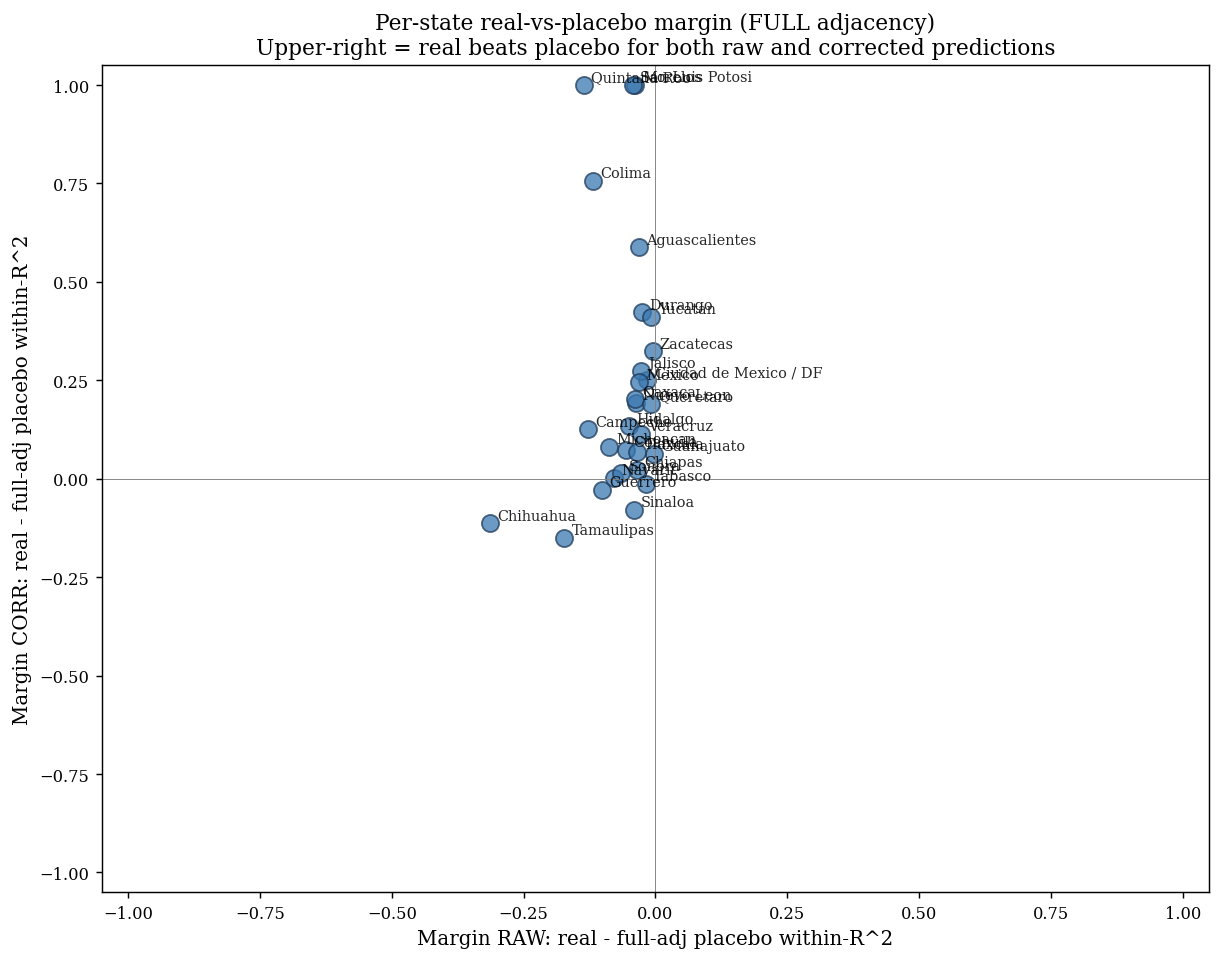

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_per_state_placebo_margin_full_adj.png


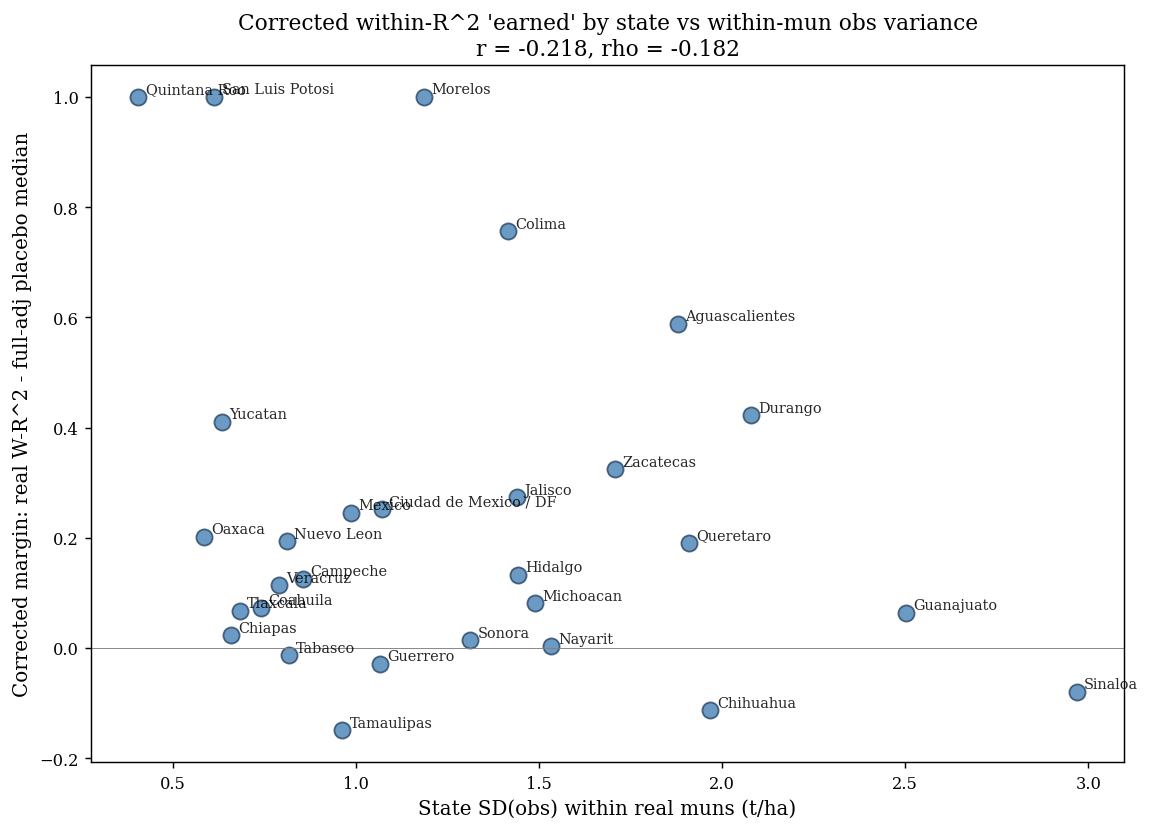

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_corrected_margin_vs_sd_obs.png

State-level summary (full-adj, corrected predictions sorted by margin):
           state_name  real_corr  placebo_full_corr_med  margin_corr  sd_obs_within  n_muns
              Morelos     -1.190                 -3.604       +1.000         +1.187      33
      San Luis Potosi     -0.039                 -1.899       +1.000         +0.614      58
         Quintana Roo     -0.063                 -1.621       +1.000         +0.406       7
               Colima     -0.228                 -0.984       +0.756         +1.415      10
       Aguascalientes     +0.109                 -0.479       +0.588         +1.879      11
              Durango     +0.233                 -0.189       +0.422         +2.078      37
              Yucatan     -0.120                 -0.531       +0.411         +0.635      92
            Zacatecas     +0.110                 -0.214       +0.324     

In [21]:
# Updated margin scatter using full-adjacency placebos.
# Also: per-state variance decomposition - show that the corrected within-R^2 is "earned"
# in proportion to how much obs variance there is within muns.

psf2 = per_state_full.copy()
psf2["n_muns"] = psf2["state"].map(df_eval.groupby("state")["muncode"].nunique().to_dict())
psf2["n_rows"] = psf2["state"].map(df_eval.groupby("state").size().to_dict())
psf2 = psf2[(psf2["n_muns"] >= 5) & (psf2["n_rows"] >= 200)].copy()
psf2["margin_raw"]  = (psf2["real_raw"]  - psf2["placebo_full_raw_med"]).clip(-1, 1)
psf2["margin_corr"] = (psf2["real_corr"] - psf2["placebo_full_corr_med"]).clip(-1, 1)

# Per-state SD(obs) within real muns (proxy for how much variance there is to explain)
def sd_obs_within(df, y, gc):
    s = df[[y, gc]].dropna()
    cnt = s.groupby(gc).size()
    s = s[s[gc].isin(cnt[cnt>=2].index)]
    gm = s.groupby(gc)[y].transform("mean")
    return float((s[y] - gm).std(ddof=0))
sd_obs_per_state = {st: sd_obs_within(df_eval[df_eval["state"]==st], "yield", "muncode")
                     for st in psf2["state"]}
psf2["sd_obs_within"] = psf2["state"].map(sd_obs_per_state)

# Margin scatter (full-adj)
fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.scatter(psf2["margin_raw"], psf2["margin_corr"], s=90, color="#3a78b0",
            edgecolor="#1f3b5a", alpha=0.75)
for _, r in psf2.iterrows():
    ax.annotate(r["state_name"], (r["margin_raw"], r["margin_corr"]),
                fontsize=8, alpha=0.85, xytext=(4,2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("Margin RAW: real - full-adj placebo within-R^2")
ax.set_ylabel("Margin CORR: real - full-adj placebo within-R^2")
ax.set_title("Per-state real-vs-placebo margin (FULL adjacency)\n"
              "Upper-right = real beats placebo for both raw and corrected predictions")
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
fig_margin_full = os.path.join(out_dir, "fig_per_state_placebo_margin_full_adj.png")
fig.savefig(fig_margin_full, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_margin_full}")

# State-level: does the corrected margin scale with within-mun obs variance?
fig, ax = plt.subplots(figsize=(9, 6.5))
sub = psf2.dropna(subset=["sd_obs_within","margin_corr"]).copy()
ax.scatter(sub["sd_obs_within"], sub["margin_corr"], s=80, color="#3a78b0",
            edgecolor="#1f3b5a", alpha=0.75)
for _, r in sub.iterrows():
    ax.annotate(r["state_name"], (r["sd_obs_within"], r["margin_corr"]),
                fontsize=8, alpha=0.85, xytext=(4,2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.5)
rp = sub[["sd_obs_within","margin_corr"]].corr().iloc[0,1]
rs = sub[["sd_obs_within","margin_corr"]].corr(method="spearman").iloc[0,1]
ax.set_xlabel("State SD(obs) within real muns (t/ha)")
ax.set_ylabel("Corrected margin: real W-R^2 - full-adj placebo median")
ax.set_title(f"Corrected within-R^2 'earned' by state vs within-mun obs variance\n"
              f"r = {rp:+.3f}, rho = {rs:+.3f}")
plt.tight_layout()
fig_earned = os.path.join(out_dir, "fig_corrected_margin_vs_sd_obs.png")
fig.savefig(fig_earned, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_earned}")

print("\nState-level summary (full-adj, corrected predictions sorted by margin):")
print(sub.sort_values("margin_corr", ascending=False)
        [["state_name","real_corr","placebo_full_corr_med","margin_corr","sd_obs_within","n_muns"]]
        .to_string(index=False, float_format=lambda x: f"{x:+.3f}"))


#### Extension F - Within-mun rank correlation (Spearman) + top/bottom muns table

Within-R^2 is depressed by variance compression: SD(pred)/SD(obs) ~ 0.71 within muns, so even with perfect rank-ordering the metric can't exceed 0.71. Spearman correlation is invariant to monotone transformations and captures whether the model rank-orders ADCs correctly *within* each mun. Compute per-mun rho, pool, compare to within-R^2.

Per-mun Spearman rho on raw predictions...


  1,538 muns (n>=5)
  mean rho=+0.194  median rho=+0.214
  pos rho: 74.97%  neg rho: 24.64%

Per-mun Spearman rho on corrected predictions...


  1,523 muns
  mean rho=+0.194  median rho=+0.214

Pooled within-mun Spearman rho:
  RAW  predictions: +0.3342  (vs Pearson within-rho 0.4620, vs W-R^2 +0.152)
  CORR predictions: +0.3343                                   (vs W-R^2 +0.154)



Muns with within-R^2 < 0 but Spearman rho > 0.3: 170  (of 998 negative-R^2 muns)


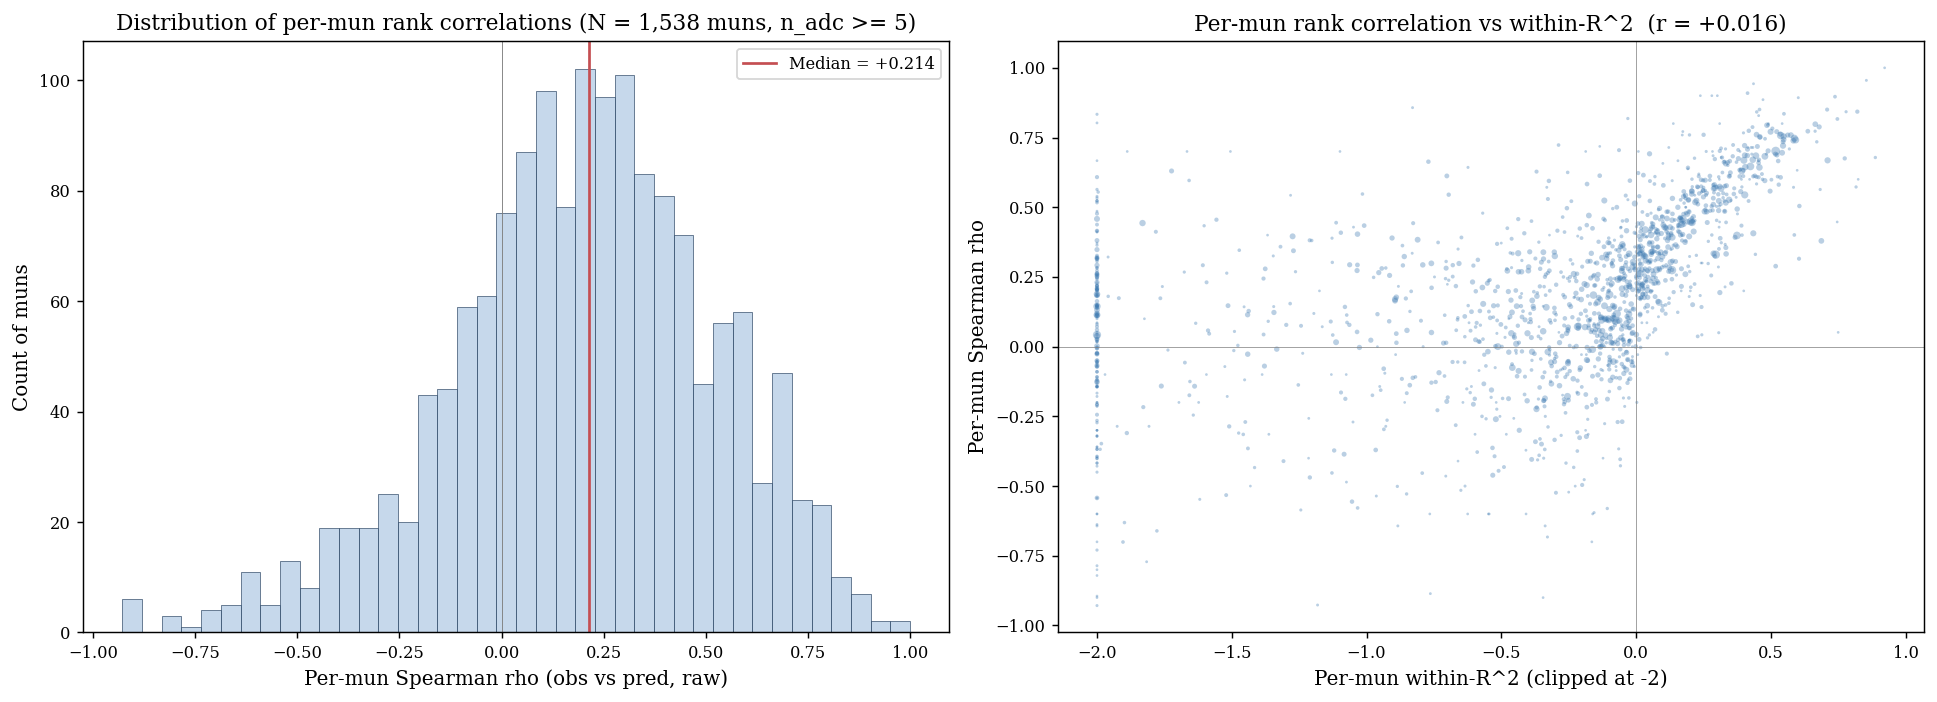

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_within_mun_spearman.png


In [22]:
# Per-mun Spearman rank correlation between obs and pred within each mun
from scipy.stats import spearmanr

def per_mun_rho(df, y, p, gc, min_n=5):
    s = df[[y,p,gc]].dropna()
    cnt = s.groupby(gc).size()
    s = s[s[gc].isin(cnt[cnt>=min_n].index)]
    out = []
    for g, sub in s.groupby(gc):
        rho, _ = spearmanr(sub[y], sub[p])
        out.append({gc:g, "n":len(sub), "rho":rho, "obs_mean":sub[y].mean(), "pred_mean":sub[p].mean()})
    return pd.DataFrame(out)

print("Per-mun Spearman rho on raw predictions...")
mun_rho_raw = per_mun_rho(df_eval, "yield", "pred", "muncode", min_n=5)
mun_rho_raw = mun_rho_raw.dropna(subset=["rho"])
print(f"  {len(mun_rho_raw):,} muns (n>=5)")
print(f"  mean rho={mun_rho_raw['rho'].mean():+.3f}  median rho={mun_rho_raw['rho'].median():+.3f}")
print(f"  pos rho: {(mun_rho_raw['rho']>0).mean():.2%}  neg rho: {(mun_rho_raw['rho']<0).mean():.2%}")

print("\nPer-mun Spearman rho on corrected predictions...")
mun_rho_corr = per_mun_rho(df_corr, "yield", "pred_corr", "muncode", min_n=5)
mun_rho_corr = mun_rho_corr.dropna(subset=["rho"])
print(f"  {len(mun_rho_corr):,} muns")
print(f"  mean rho={mun_rho_corr['rho'].mean():+.3f}  median rho={mun_rho_corr['rho'].median():+.3f}")

# Pooled within-mun Spearman: rank within each mun, then compute correlation on demeaned ranks
def pooled_within_rho(df, y, p, gc, min_n=5):
    s = df[[y,p,gc]].dropna().copy()
    cnt = s.groupby(gc).size()
    s = s[s[gc].isin(cnt[cnt>=min_n].index)]
    s["obs_rank"]  = s.groupby(gc)[y].rank()
    s["pred_rank"] = s.groupby(gc)[p].rank()
    gm = s.groupby(gc)[["obs_rank","pred_rank"]].transform("mean")
    do = s["obs_rank"] - gm["obs_rank"]
    dp = s["pred_rank"] - gm["pred_rank"]
    if do.std() == 0 or dp.std() == 0: return np.nan
    return (do * dp).mean() / (do.std(ddof=0) * dp.std(ddof=0))

pooled_rho_raw  = pooled_within_rho(df_eval, "yield", "pred", "muncode", min_n=5)
pooled_rho_corr = pooled_within_rho(df_corr, "yield", "pred_corr", "muncode", min_n=5)
print(f"\nPooled within-mun Spearman rho:")
print(f"  RAW  predictions: {pooled_rho_raw:+.4f}  (vs Pearson within-rho {0.462:.4f}, vs W-R^2 +0.152)")
print(f"  CORR predictions: {pooled_rho_corr:+.4f}                                   (vs W-R^2 +0.154)")

# Per-state pooled within-mun Spearman rho
state_rho_raw  = {st: pooled_within_rho(df_eval[df_eval["state"]==st], "yield","pred","muncode",min_n=5)
                    for st in df_eval["state"].unique()}
state_rho_corr = {st: pooled_within_rho(df_corr[df_corr["state"]==st], "yield","pred_corr","muncode",min_n=5)
                    for st in df_corr["state"].unique()}

# Plot: per-mun rho histogram + scatter vs within-R^2
mun_r2 = pd.read_csv(mun_r2_csv, dtype={"muncode":str})
mun_r2["muncode"] = mun_r2["muncode"].str.zfill(5)
comp = mun_rho_raw.merge(mun_r2[["muncode","within_r2","n_rows"]], on="muncode")
print(f"\nMuns with within-R^2 < 0 but Spearman rho > 0.3: {((comp['within_r2']<0)&(comp['rho']>0.3)).sum():,}  "
      f"(of {len(comp[comp['within_r2']<0]):,} negative-R^2 muns)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.hist(mun_rho_raw["rho"], bins=40, color="#bcd2e8", edgecolor="#1f3b5a", linewidth=0.4, alpha=0.85)
ax.axvline(0, color="grey", lw=0.5)
ax.axvline(mun_rho_raw["rho"].median(), color="#c44e52", lw=1.5,
            label=f"Median = {mun_rho_raw['rho'].median():+.3f}")
ax.set_xlabel("Per-mun Spearman rho (obs vs pred, raw)")
ax.set_ylabel("Count of muns")
ax.set_title(f"Distribution of per-mun rank correlations (N = {len(mun_rho_raw):,} muns, n_adc >= 5)")
ax.legend()

ax = axes[1]
sz = np.sqrt(comp["n_rows"].clip(lower=1)) * 1.0
ax.scatter(comp["within_r2"].clip(lower=R2_CLIP_LO), comp["rho"], s=sz,
            color="#3a78b0", edgecolor="none", alpha=0.35, rasterized=True)
ax.axhline(0, color="grey", lw=0.4); ax.axvline(0, color="grey", lw=0.4)
ax.set_xlabel("Per-mun within-R^2 (clipped at -2)")
ax.set_ylabel("Per-mun Spearman rho")
rp = comp[["within_r2","rho"]].corr().iloc[0,1]
ax.set_title(f"Per-mun rank correlation vs within-R^2  (r = {rp:+.3f})")

plt.tight_layout()
fig_rank = os.path.join(out_dir, "fig_within_mun_spearman.png")
fig.savefig(fig_rank, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_rank}")


In [23]:
# Top-10 / bottom-10 muns appendix table (annotated with state, parcel size, irrigation, etc.)
mun_r2 = pd.read_csv(mun_r2_csv, dtype={"muncode":str})
mun_r2["muncode"] = mun_r2["muncode"].str.zfill(5)
mun_r2["state"]   = mun_r2["muncode"].str[:2]

# Merge with parcel size + Spearman rho + state name
parcel = mun_psize[["muncode","mean_parcel_ha","tot_land","tot_up"]].copy()
parcel["muncode"] = parcel["muncode"].str.zfill(5)
table = mun_r2.merge(parcel, on="muncode", how="left")
table = table.merge(mun_rho_raw[["muncode","rho"]], on="muncode", how="left")
table = table.merge(state_names, on="state", how="left")

# Filter to "interesting" muns: at least 20 ADCs so within-R^2 is well-estimated
table = table[table["n_rows"] >= 20].copy()
print(f"Filtered to muns with >= 20 INEGI rows: {len(table):,}")

top10 = table.nlargest(10, "within_r2")[["muncode","state_name","within_r2","rho","n_rows","sd_obs","mean_obs","mean_parcel_ha"]]
bot10 = table.nsmallest(10, "within_r2")[["muncode","state_name","within_r2","rho","n_rows","sd_obs","mean_obs","mean_parcel_ha"]]
print("\nTop 10 muns by within-R^2:")
print(top10.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
print("\nBottom 10 muns by within-R^2:")
print(bot10.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

# Persist
top10.to_csv(os.path.join(out_dir, "top10_muns_within_r2.csv"), index=False)
bot10.to_csv(os.path.join(out_dir, "bottom10_muns_within_r2.csv"), index=False)

# LaTeX
def to_latex(df, label, caption):
    lines = [r"\begin{table}[H]\centering", r"\small",
             r"\caption{" + caption + "}", r"\label{tab:" + label + "}",
             r"\begin{tabular}{lllrrrrr}", r"\toprule",
             r"Mun & State & $W$-$R^2$ & $\rho_S$ & $N$ & SD(obs) & Mean(obs) & Parcel (ha) \\", r"\midrule"]
    for _, r in df.iterrows():
        lines.append(f"{r['muncode']} & {r['state_name'][:20]} & "
                      f"{r['within_r2']:+.3f} & {r['rho']:+.3f} & {int(r['n_rows'])} & "
                      f"{r['sd_obs']:.2f} & {r['mean_obs']:.2f} & {r['mean_parcel_ha']:.2f} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)

with open(os.path.join(out_dir, "top_bottom_muns.tex"), "w") as f:
    f.write(to_latex(top10, "top10_muns", "Top 10 municipalities by within-mun $R^2$ (n_adc $\\geq$ 20)") + "\n\n")
    f.write(to_latex(bot10, "bot10_muns", "Bottom 10 municipalities by within-mun $R^2$ (n_adc $\\geq$ 20)"))
print(f"\nSaved {os.path.join(out_dir, 'top_bottom_muns.tex')}")


Filtered to muns with >= 20 INEGI rows: 968

Top 10 muns by within-R^2:
muncode     state_name  within_r2    rho  n_rows  sd_obs  mean_obs  mean_parcel_ha
  22012      Queretaro     +0.821 +0.843      32  +3.885    +5.762          +2.200
  08012      Chihuahua     +0.774 +0.675      33  +3.563    +2.912          +2.572
  29007       Tlaxcala     +0.747 +0.817      20  +0.717    +1.000          +1.457
  22016      Queretaro     +0.711 +0.668     143  +3.466    +2.797          +1.660
  01007 Aguascalientes     +0.709 +0.850      27  +2.144    +2.646          +3.350
  13015        Hidalgo     +0.688 +0.379     102  +1.489    +0.617          +1.093
  11011     Guanajuato     +0.680 +0.788      66  +3.738    +5.139          +3.088
  13030        Hidalgo     +0.665 +0.798      97  +2.790    +3.852          +0.742
  13064        Hidalgo     +0.637 +0.773      48  +3.220    +3.095          +0.773
  20207         Oaxaca     +0.606 +0.504      38  +0.394    +0.942          +2.741

Bottom 10 muns

#### Extension G - ADC-level calibration hexbin (pred vs obs)

Quick visual: predicted vs observed maize yield at the ADC level, with identity line. Raw and additive-corrected side by side. The hexbin density and deviation from the identity line make calibration bias visible at a glance.

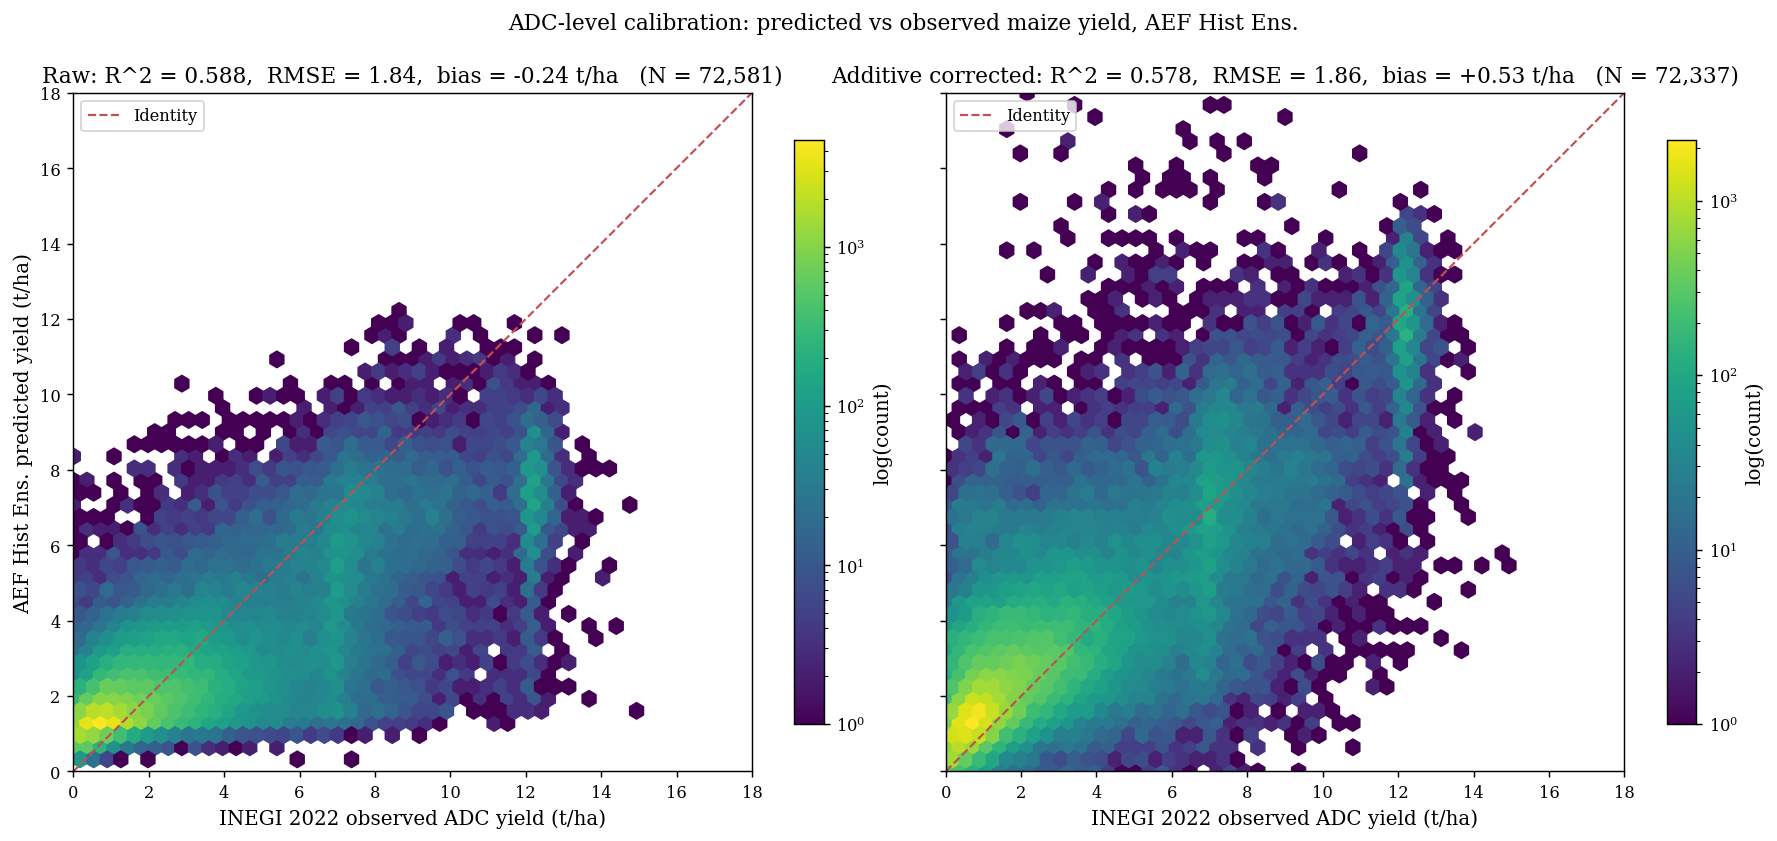

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_calibration_hexbin.png


In [24]:
# Calibration hexbin: predicted vs observed ADC yields, raw and corrected
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, pcol, label in [(axes[0], "pred", "Raw"),
                          (axes[1], "pred_corr", "Additive corrected")]:
    src_df = df_eval if pcol == "pred" else df_corr
    s = src_df[["yield", pcol]].dropna()
    s = s[(s["yield"] >= 0) & (s["yield"] <= 20) & (s[pcol] >= 0) & (s[pcol] <= 20)]
    hb = ax.hexbin(s["yield"], s[pcol], gridsize=50, mincnt=1, cmap="viridis",
                    extent=(0, 18, 0, 18), bins="log")
    ax.plot([0, 18], [0, 18], color="#c44e52", linestyle="--", lw=1.2, label="Identity")
    rsq  = r2(s["yield"], s[pcol])
    rmse = float(np.sqrt(((s["yield"] - s[pcol])**2).mean()))
    bias = float((s[pcol] - s["yield"]).mean())
    ax.set_xlim(0, 18); ax.set_ylim(0, 18)
    ax.set_aspect("equal")
    ax.set_xlabel("INEGI 2022 observed ADC yield (t/ha)")
    if pcol == "pred":
        ax.set_ylabel("AEF Hist Ens. predicted yield (t/ha)")
    ax.set_title(f"{label}: R^2 = {rsq:.3f},  RMSE = {rmse:.2f},  bias = {bias:+.2f} t/ha   (N = {len(s):,})")
    ax.legend(loc="upper left", fontsize=9)
    fig.colorbar(hb, ax=ax, shrink=0.85, label="log(count)")

plt.suptitle("ADC-level calibration: predicted vs observed maize yield, AEF Hist Ens.",
              y=1.02)
plt.tight_layout()
fig_hex = os.path.join(out_dir, "fig_calibration_hexbin.png")
fig.savefig(fig_hex, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_hex}")


#### Extension H - Multi-year mun-level stability against SIAP (2017-2024)

The within-R^2 analysis used INEGI 2022 ground truth (only year available). But the predictions cover 2017-2024 and SIAP municipal maize yields are available for every year. Test mun-level stability of the model across years: aggregate ADC predictions to area-weighted mun means and compare to SIAP per-year yields. Does the mun-level R^2 stay near the 2022 between-R^2 of ~0.74 across years, or is 2022 an outlier?

RF baseline predictions: 1,010,680 rows, cols=['adcid', 'year', 'yield_pred'], years=[np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Using pred col 'yield_pred'


Mun-year predictions: 19,368 (covers 2017-2024)


Mun-year panel: 18,592 rows (2364 unique muns, 8 years)

Multi-year RF-baseline mun-level accuracy:
 year  N_muns    R2  RMSE   bias  obs_mean  pred_mean
 2017    2323 0.794 1.010  0.009     2.531      2.540
 2018    2314 0.778 1.073 -0.026     2.534      2.509
 2019    2336 0.781 1.101  0.005     2.476      2.481
 2020    2325 0.809 0.986  0.040     2.484      2.524
 2021    2322 0.793 1.047 -0.001     2.625      2.623
 2022    2319 0.788 1.133 -0.070     2.694      2.624
 2023    2334 0.749 1.192 -0.030     2.634      2.605
 2024    2319 0.769 1.178 -0.020     2.752      2.731


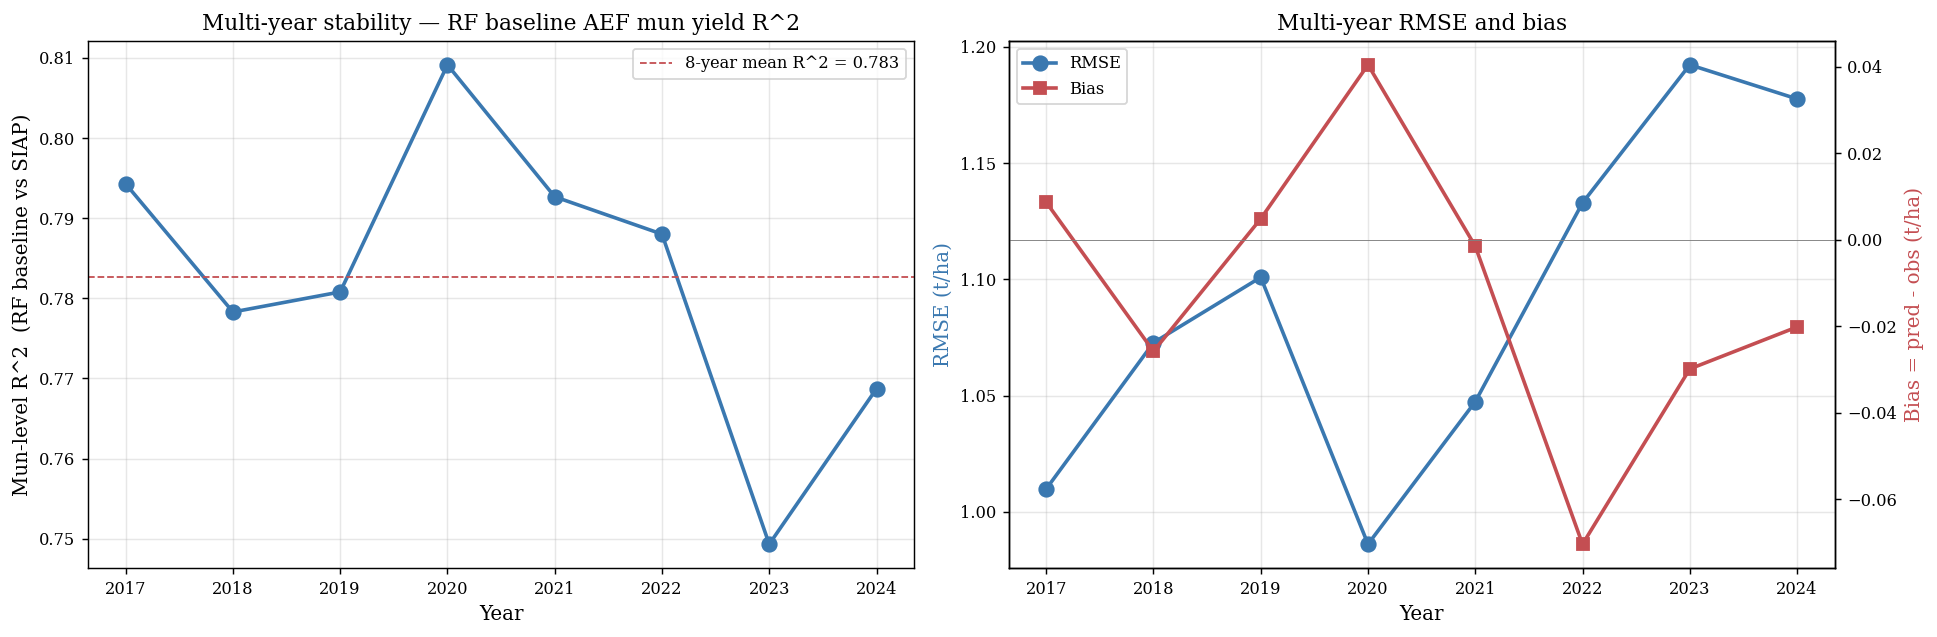

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_multiyear_mun_stability.png


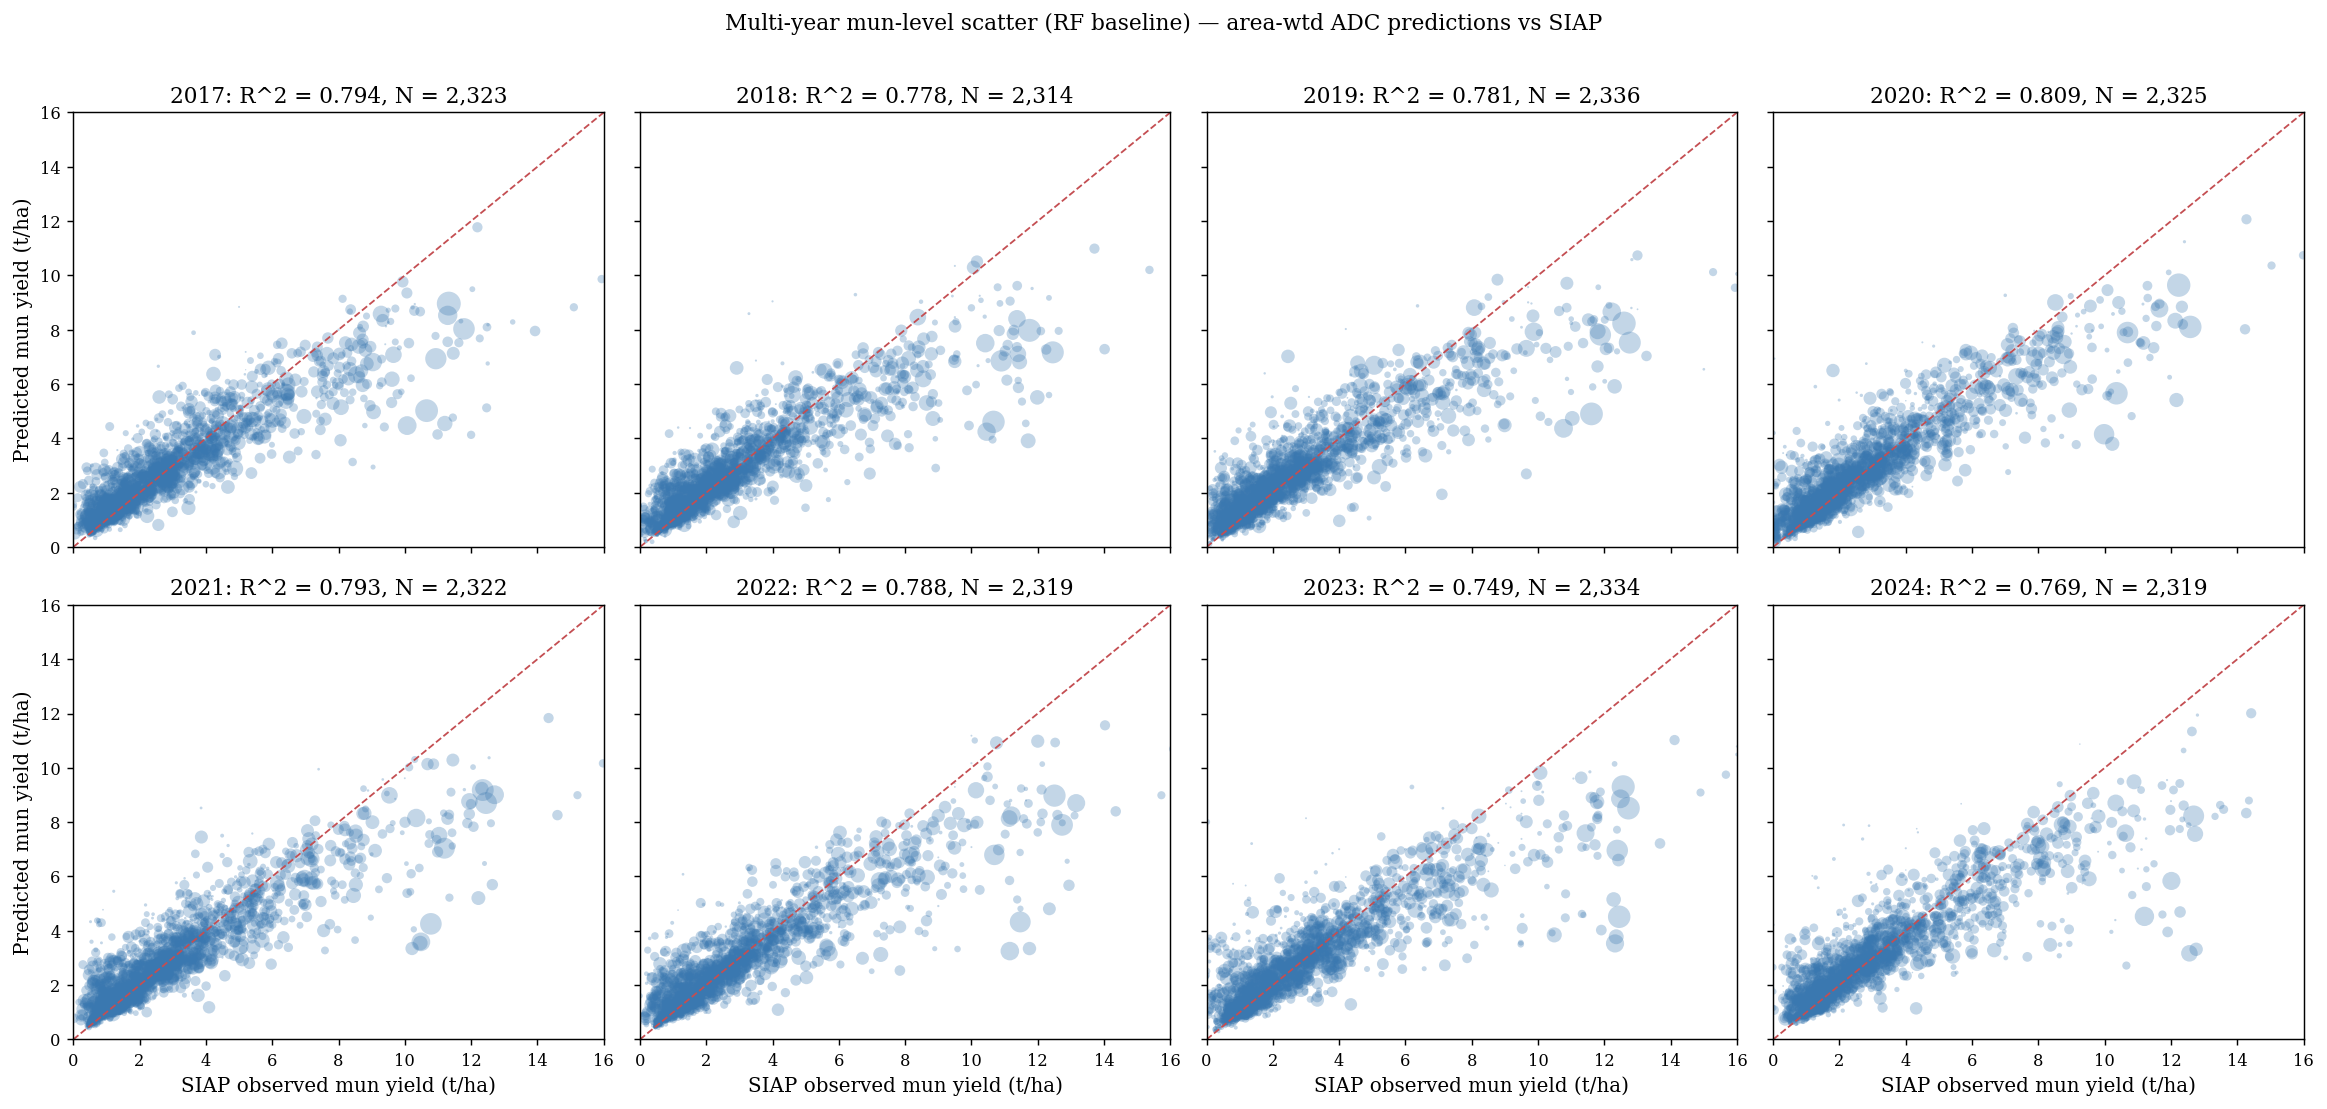

Saved /home/jdesktop/Dropbox/Projects/Maize_prediction/plots/coauthor_extras_paper/fig_multiyear_mun_scatter.png


In [25]:
# Multi-year mun-level stability — using the RF BASELINE model (the headline AEF Hist Ens
# predictions cover 2022 only; RF baseline covers 2017–2024). RF baseline is paper-relevant
# (Table 1's first row family) and provides the temporal stability check.

agland_csv = os.path.join(data_dir, "SIAP_agland", "Output", "2007_adcs_agland_area.csv")
rf_preds_path = os.path.join(preds_dir, "adc_alpha_earth_preds_maize.parquet")
preds_full = pd.read_parquet(rf_preds_path)
print(f"RF baseline predictions: {len(preds_full):,} rows, cols={list(preds_full.columns)}, "
      f"years={sorted(preds_full['year'].unique())}")

# Normalize id column (use 'adc' without dash)
if "adc" not in preds_full.columns and "adcid" in preds_full.columns:
    preds_full = preds_full.rename(columns={"adcid":"adc"})
preds_full["adc"] = preds_full["adc"].astype(str).str.replace("-","",regex=False)
if "muncode" not in preds_full.columns:
    preds_full["muncode"] = preds_full["adc"].str[:5]
pred_col = "yield_pred" if "yield_pred" in preds_full.columns else "pred"
print(f"Using pred col '{pred_col}'")

agland = pd.read_csv(agland_csv)
agland.columns = [c.lower() for c in agland.columns]
agland["adc"] = agland["adc07"].astype(str).str.replace("-","",regex=False)
adc_area = agland[["adc","adc_area"]]

preds = preds_full.merge(adc_area, on="adc", how="left")
preds["adc_area"] = preds["adc_area"].fillna(1.0)
preds["w"] = preds["adc_area"].clip(lower=1e-6)
preds["wp"] = preds["w"] * preds[pred_col]
preds = preds.dropna(subset=[pred_col])

mun_pred = (preds.groupby(["muncode","year"], as_index=False)
                  .agg(wp_sum=("wp","sum"), w_sum=("w","sum")))
mun_pred["pred_mun"] = mun_pred["wp_sum"] / mun_pred["w_sum"].replace(0, np.nan)
mun_pred = mun_pred.dropna(subset=["pred_mun"])
mun_pred["muncode"] = mun_pred["muncode"].astype(str).str.zfill(5)
mun_pred["year"] = mun_pred["year"].astype(int)
print(f"Mun-year predictions: {len(mun_pred):,} (covers {mun_pred['year'].min()}-{mun_pred['year'].max()})")

siap_yr = pd.read_stata(siap_ca07_dta, columns=["year","muncode","name","q","ha_planted"])
siap_yr = siap_yr[(siap_yr["name"]=="Maize") & siap_yr["year"].between(2017, 2024)].copy()
siap_yr["yield"] = siap_yr["q"] / siap_yr["ha_planted"].replace(0, np.nan)
siap_yr = siap_yr.dropna(subset=["yield"])
siap_yr["muncode"] = siap_yr["muncode"].astype(str).str.zfill(5)
siap_yr["year"] = siap_yr["year"].astype(int)

panel = mun_pred.merge(siap_yr[["muncode","year","yield","ha_planted"]], on=["muncode","year"], how="inner")
print(f"Mun-year panel: {len(panel):,} rows ({panel['muncode'].nunique()} unique muns, {panel['year'].nunique()} years)")

years = sorted(panel["year"].unique())
res = []
for yr in years:
    sub = panel[panel["year"] == yr]
    R2  = r2(sub["yield"], sub["pred_mun"])
    RMS = float(np.sqrt(((sub["yield"] - sub["pred_mun"])**2).mean()))
    bias = float((sub["pred_mun"] - sub["yield"]).mean())
    res.append({"year":yr, "N_muns":len(sub), "R2":R2, "RMSE":RMS, "bias":bias,
                "obs_mean":float(sub["yield"].mean()), "pred_mean":float(sub["pred_mun"].mean())})
multiyear = pd.DataFrame(res)
print("\nMulti-year RF-baseline mun-level accuracy:")
print(multiyear.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
multiyear.to_csv(os.path.join(out_dir, "multiyear_mun_accuracy.csv"), index=False)

# Plot: per-year R^2 and RMSE/bias
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(multiyear["year"], multiyear["R2"], "-o", color="#3a78b0", lw=2, ms=8)
ax.axhline(multiyear["R2"].mean(), color="#c44e52", lw=1, linestyle="--",
            label=f"8-year mean R^2 = {multiyear['R2'].mean():.3f}")
ax.set_xlabel("Year"); ax.set_ylabel("Mun-level R^2  (RF baseline vs SIAP)")
ax.set_title("Multi-year stability — RF baseline AEF mun yield R^2")
ax.legend(loc="best"); ax.grid(alpha=0.3)

ax = axes[1]
ax2 = ax.twinx()
ax.plot(multiyear["year"], multiyear["RMSE"], "-o", color="#3a78b0", lw=2, ms=8, label="RMSE")
ax2.plot(multiyear["year"], multiyear["bias"], "-s", color="#c44e52", lw=2, ms=7, label="Bias")
ax2.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Year"); ax.set_ylabel("RMSE (t/ha)", color="#3a78b0")
ax2.set_ylabel("Bias = pred - obs (t/ha)", color="#c44e52")
ax.set_title("Multi-year RMSE and bias"); ax.grid(alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
fig_multiyear = os.path.join(out_dir, "fig_multiyear_mun_stability.png")
fig.savefig(fig_multiyear, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_multiyear}")

# Per-year scatter (8-panel)
n_yrs = len(years)
ncol = 4
nrow = (n_yrs + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5*ncol, 4.2*nrow), sharex=True, sharey=True)
axes = np.atleast_2d(axes)
for ax_i, yr in zip(axes.flatten(), years):
    sub = panel[panel["year"] == yr]
    sz = np.sqrt(sub["ha_planted"].clip(lower=1)) * 0.5
    ax_i.scatter(sub["yield"], sub["pred_mun"], s=sz, alpha=0.3, color="#3a78b0",
                  edgecolor="none", rasterized=True)
    ax_i.plot([0, 16], [0, 16], color="#c44e52", linestyle="--", lw=1)
    R2  = r2(sub["yield"], sub["pred_mun"])
    ax_i.set_title(f"{yr}: R^2 = {R2:.3f}, N = {len(sub):,}")
    ax_i.set_xlim(0, 16); ax_i.set_ylim(0, 16)
for ax in axes[-1, :]: ax.set_xlabel("SIAP observed mun yield (t/ha)")
for ax in axes[:, 0]:  ax.set_ylabel("Predicted mun yield (t/ha)")
for ax in axes.flatten()[n_yrs:]: ax.set_visible(False)
plt.suptitle("Multi-year mun-level scatter (RF baseline) — area-wtd ADC predictions vs SIAP", y=1.01)
plt.tight_layout()
fig_scatter = os.path.join(out_dir, "fig_multiyear_mun_scatter.png")
fig.savefig(fig_scatter, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_scatter}")


#### Extension I - Between-R^2 vs Within-R^2 by state

Task 2's bar plot showed total + within R^2 but omitted between-R^2. Add it: grouped bars (total / between / within), the between-minus-within gap by state, and a scatter of between vs within (one dot per state).

In [ ]:
# Between-R^2 vs Within-R^2 by state -- the decomposition Task 2 was missing
sr_full = pd.read_csv(state_acc_csv, dtype={"state":str})
sr_full["state"] = sr_full["state"].str.zfill(2)

# Restrict to raw, combined; drop states with too few muns
sr_bw = sr_full.query("season=='Combined' and model=='Raw'").copy()
sr_bw = sr_bw[sr_bw["n_mun"] >= 5].copy()
sr_bw = sr_bw.sort_values("Between_R2", ascending=False).reset_index(drop=True)

VIS_CLIP = -1.0
WIDTH = 0.27

fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)
x = np.arange(len(sr_bw))

# Top panel: grouped bars (total, between, within), sorted by Between
ax = axes[0]
ax.bar(x - WIDTH, sr_bw["R2"].clip(lower=VIS_CLIP),         width=WIDTH,
        color="#3a78b0", edgecolor="#222", linewidth=0.3, label="Total R^2")
ax.bar(x,         sr_bw["Between_R2"].clip(lower=VIS_CLIP), width=WIDTH,
        color="#7fbf7b", edgecolor="#222", linewidth=0.3, label="Between-mun R^2")
ax.bar(x + WIDTH, sr_bw["Within_R2"].clip(lower=VIS_CLIP),  width=WIDTH,
        color="#e3a857", edgecolor="#222", linewidth=0.3, label="Within-mun R^2")
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("State R^2 (clipped at -1)")
ax.set_title("State-level total / between-mun / within-mun R^2 -- AEF Hist Ens. raw, combined, INEGI 2022")
ax.legend(loc="upper right")
ax.set_ylim(VIS_CLIP - 0.05, 1.05)

# Bottom panel: between - within margin (gap) per state, signed
ax = axes[1]
sr_bw["gap"] = sr_bw["Between_R2"] - sr_bw["Within_R2"]
colors = ["#3a78b0" if g >= 0 else "#c44e52" for g in sr_bw["gap"]]
ax.bar(x, sr_bw["gap"].clip(lower=VIS_CLIP, upper=2.0), color=colors, edgecolor="#222", linewidth=0.3)
ax.axhline(0, color="grey", lw=0.5)
ax.set_ylabel("Between R^2 - Within R^2  (positive = big mun-level signal, small within signal)")
ax.set_title("State gap: Between-R^2 minus Within-R^2")
ax.set_xticks(x)
ax.set_xticklabels(sr_bw["state_name"], rotation=70, ha="right", fontsize=8.5)

plt.tight_layout()
fig_bw_bars = os.path.join(out_dir, "fig_state_between_vs_within_bars.png")
fig.savefig(fig_bw_bars, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_bw_bars}")

# Scatter: between R^2 vs within R^2 per state
fig, ax = plt.subplots(figsize=(9.5, 8))
sizes = np.sqrt(sr_bw["n_mun"].clip(lower=1)) * 8
ax.scatter(sr_bw["Between_R2"].clip(lower=VIS_CLIP),
            sr_bw["Within_R2"].clip(lower=VIS_CLIP),
            s=sizes, color="#3a78b0", edgecolor="#1f3b5a", alpha=0.75, linewidth=0.6)
for _, r in sr_bw.iterrows():
    ax.annotate(r["state_name"],
                (max(r["Between_R2"], VIS_CLIP), max(r["Within_R2"], VIS_CLIP)),
                fontsize=7.5, alpha=0.85, xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.plot([VIS_CLIP, 1], [VIS_CLIP, 1], color="#c44e52", linestyle="--", lw=1,
         label="y = x (between == within)")

rp = sr_bw[["Between_R2","Within_R2"]].corr().iloc[0,1]
rs = sr_bw[["Between_R2","Within_R2"]].corr(method="spearman").iloc[0,1]
ax.set_xlabel("State Between-mun R^2")
ax.set_ylabel("State Within-mun R^2")
ax.set_title(f"State-level Between-R^2 vs Within-R^2  (AEF Hist Ens. raw, combined)\n"
              f"Pearson r = {rp:+.3f}, Spearman rho = {rs:+.3f}, N = {len(sr_bw)} states")
ax.legend(loc="lower right")
ax.set_xlim(VIS_CLIP - 0.05, 1.05); ax.set_ylim(VIS_CLIP - 0.05, 0.65)
plt.tight_layout()
fig_bw_scatter = os.path.join(out_dir, "fig_state_between_vs_within_scatter.png")
fig.savefig(fig_bw_scatter, bbox_inches="tight", dpi=170)
plt.show()
print(f"Saved {fig_bw_scatter}")

# Summary
print("\nState-level summary (sorted by between-R^2):")
print(sr_bw[["state_name","R2","Between_R2","Within_R2","gap","n_mun"]]
        .to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
